In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.fft import fft, fftshift, ifft, ifftshift, fftfreq
from dataclasses import dataclass
np.random.seed(17)

Util-функции

In [2]:
@dataclass
class Plot:
    x: list
    y: list
    label: str = None
    color: str = None
    linewidth: float = 1.0
    linestyle: str = "-"
    marker: str = None
    markersize: float = None
    markerevery: float = None

class Plot_Group:
    def __init__(
            self, title: str | None = None, x_label: str | None = None, y_label: str | None = None,
            legend: bool = False, legend_loc: str | None = "best", legend_fontsize: str | None = "medium",
            grid: bool = True, xlim: tuple | None = None, ylim: tuple | None = None
        ):
        self.title = title
        self.x_label = x_label
        self.y_label = y_label
        self.legend = legend
        self.legend_loc = legend_loc
        self.legend_fontsize = legend_fontsize
        self.grid = grid
        self.xlim = xlim
        self.ylim = ylim
        self.plots = list()

    def add_plot(self, Plot):
        self.plots.append(Plot)

class Chart:
    def __init__(self, rows: int = 1, cols: int = 1, width: float = 7, height: float = 5):
        self.rows = rows
        self.cols = cols
        self.width = width
        self.height = height
        self.__cur_ij = [0, 0]
        self.__plot_groups = [[None for _ in range(self.cols)] for _ in range(self.rows)]

    def add_plot_group(self, Plot_Group: Plot_Group, ij: list = None):
        if ij is None:
            if self.__cur_ij[0] >= self.rows:
                raise IndexError("Max quantity of plots achieved!")
            ij = self.__cur_ij
        while self.__plot_groups[self.__cur_ij[0]][self.__cur_ij[1]] is not None:
            self.__cur_ij[1] += 1
            if self.__cur_ij[1] >= self.cols:
                self.__cur_ij[1] = 0
                self.__cur_ij[0] += 1
        self.__plot_groups[ij[0]][ij[1]] = Plot_Group

    def __make_chart(self):
        fig, axes = plt.subplots(self.rows, self.cols, figsize=(self.width, self.height))
        if self.rows == 1 and self.cols == 1:
            axes = [[axes]]
        elif self.rows == 1:
            axes = [axes]
        elif self.cols == 1:
            axes = [[ax] for ax in axes]

        for i in range(self.rows):
            for j in range(self.cols):
                plot_group_ij = self.__plot_groups[i][j]
                if plot_group_ij is None: 
                    fig.delaxes(axes[i][j])
                    continue
                
                if plot_group_ij.title:
                    axes[i][j].set_title(plot_group_ij.title)
                if plot_group_ij.x_label:
                    axes[i][j].set_xlabel(plot_group_ij.x_label)
                if plot_group_ij.y_label:
                    axes[i][j].set_ylabel(plot_group_ij.y_label)
                for plot in plot_group_ij.plots:
                    axes[i][j].plot(
                        plot.x, plot.y,
                        label=plot.label,
                        color=plot.color,
                        linewidth=plot.linewidth,
                        linestyle=plot.linestyle,
                        marker=plot.marker,
                        markersize=plot.markersize,
                        markevery=plot.markerevery
                    )
                if plot_group_ij.legend and any(plot.label for plot in plot_group_ij.plots):
                    axes[i][j].legend(loc=plot_group_ij.legend_loc, fontsize=plot_group_ij.legend_fontsize)

                if plot_group_ij.xlim is not None:
                    axes[i][j].set_xlim(plot_group_ij.xlim[0], plot_group_ij.xlim[1])
                if plot_group_ij.ylim is not None:
                    axes[i][j].set_ylim(plot_group_ij.ylim[0], plot_group_ij.ylim[1])

                if plot_group_ij.grid: axes[i][j].grid(True)
                else: axes[i][j].grid(False)

        plt.gca().set_axisbelow(True) 
        plt.tight_layout()

    def draw_chart(self):
        self.__make_chart()
        plt.show()

    def save_chart(self, folder_path:str = "", filename:str = "chart", dpi="figure"):
        self.__make_chart()
        plt.savefig(folder_path+filename+".png", dpi=dpi)

In [3]:
def list_func(func):
    def wrapper(x_lst):
        result = []
        for x in x_lst:
            result.append(func(x))
        return result
    return wrapper

In [4]:
plt_folder = "plots/"

# Задание 1

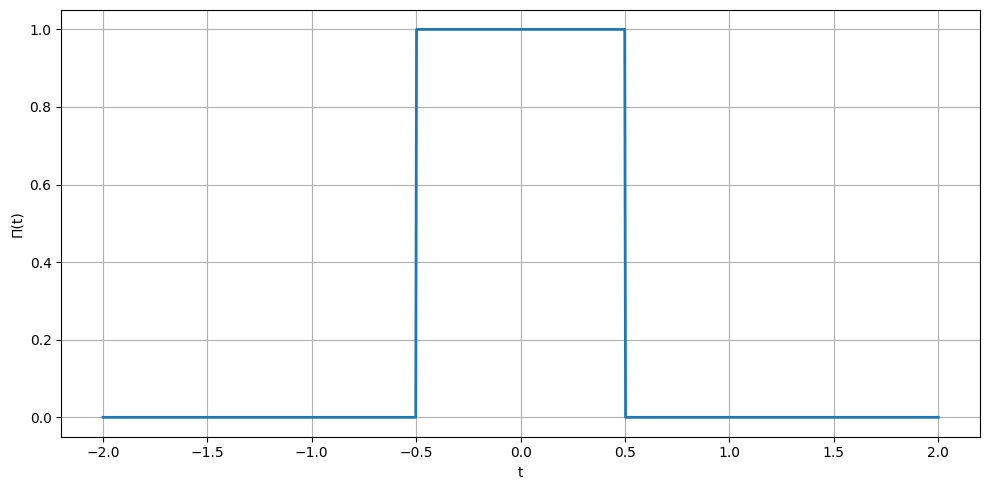

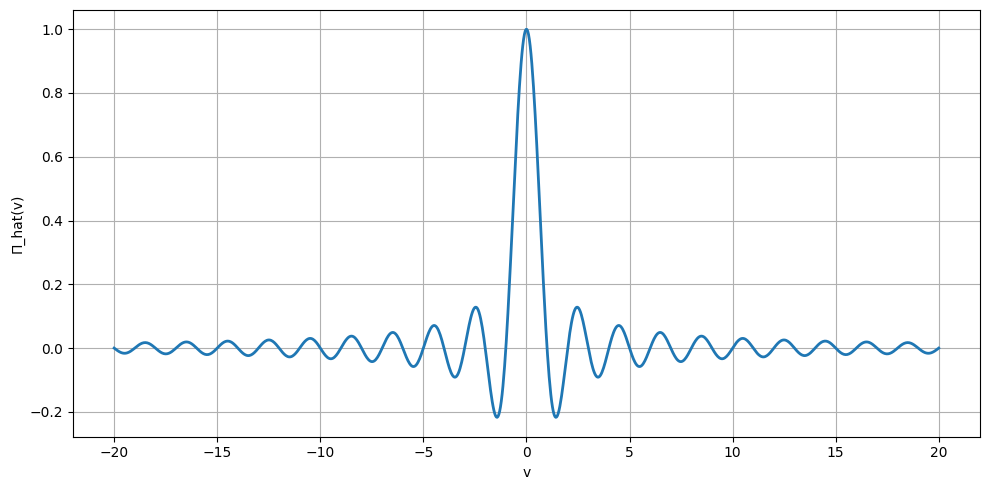

In [5]:
@list_func
def rect_func(t):
    if np.abs(t) <= 0.5: return 1
    else: return 0

@list_func
def sinc(v):
    return np.sin(np.pi * v) / (np.pi * v)

t_rect = np.linspace(-2.0, 2.0, 1000)
v_rect = np.linspace(-20.0, 20.0, 1000)

PI = rect_func(t_rect)
PI_hat = sinc(v_rect)

plt_g = Plot_Group(x_label="t", y_label="П(t)")
plt_g.add_plot(Plot(t_rect, PI, linewidth=2))
chart = Chart(width=10)
chart.add_plot_group(plt_g)
chart.save_chart(plt_folder, "П(t)", dpi=200)
del plt_g, chart

plt_g = Plot_Group(x_label="v", y_label="П_hat(v)")
plt_g.add_plot(Plot(v_rect, PI_hat, linewidth=2))
chart = Chart(width=10)
chart.add_plot_group(plt_g)
chart.save_chart(plt_folder, "П_hat(v)", dpi=200)
del plt_g, chart

# Задание 1.1

In [6]:
t_rect = np.arange(-10.0, 10.0001, 0.0001)
v_rect = np.arange(-25.0, 25.0001, 0.0001)

PI = rect_func(t_rect)
PI_hat = sinc(v_rect)

/home/ns/ros2_venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ns/ros2_venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


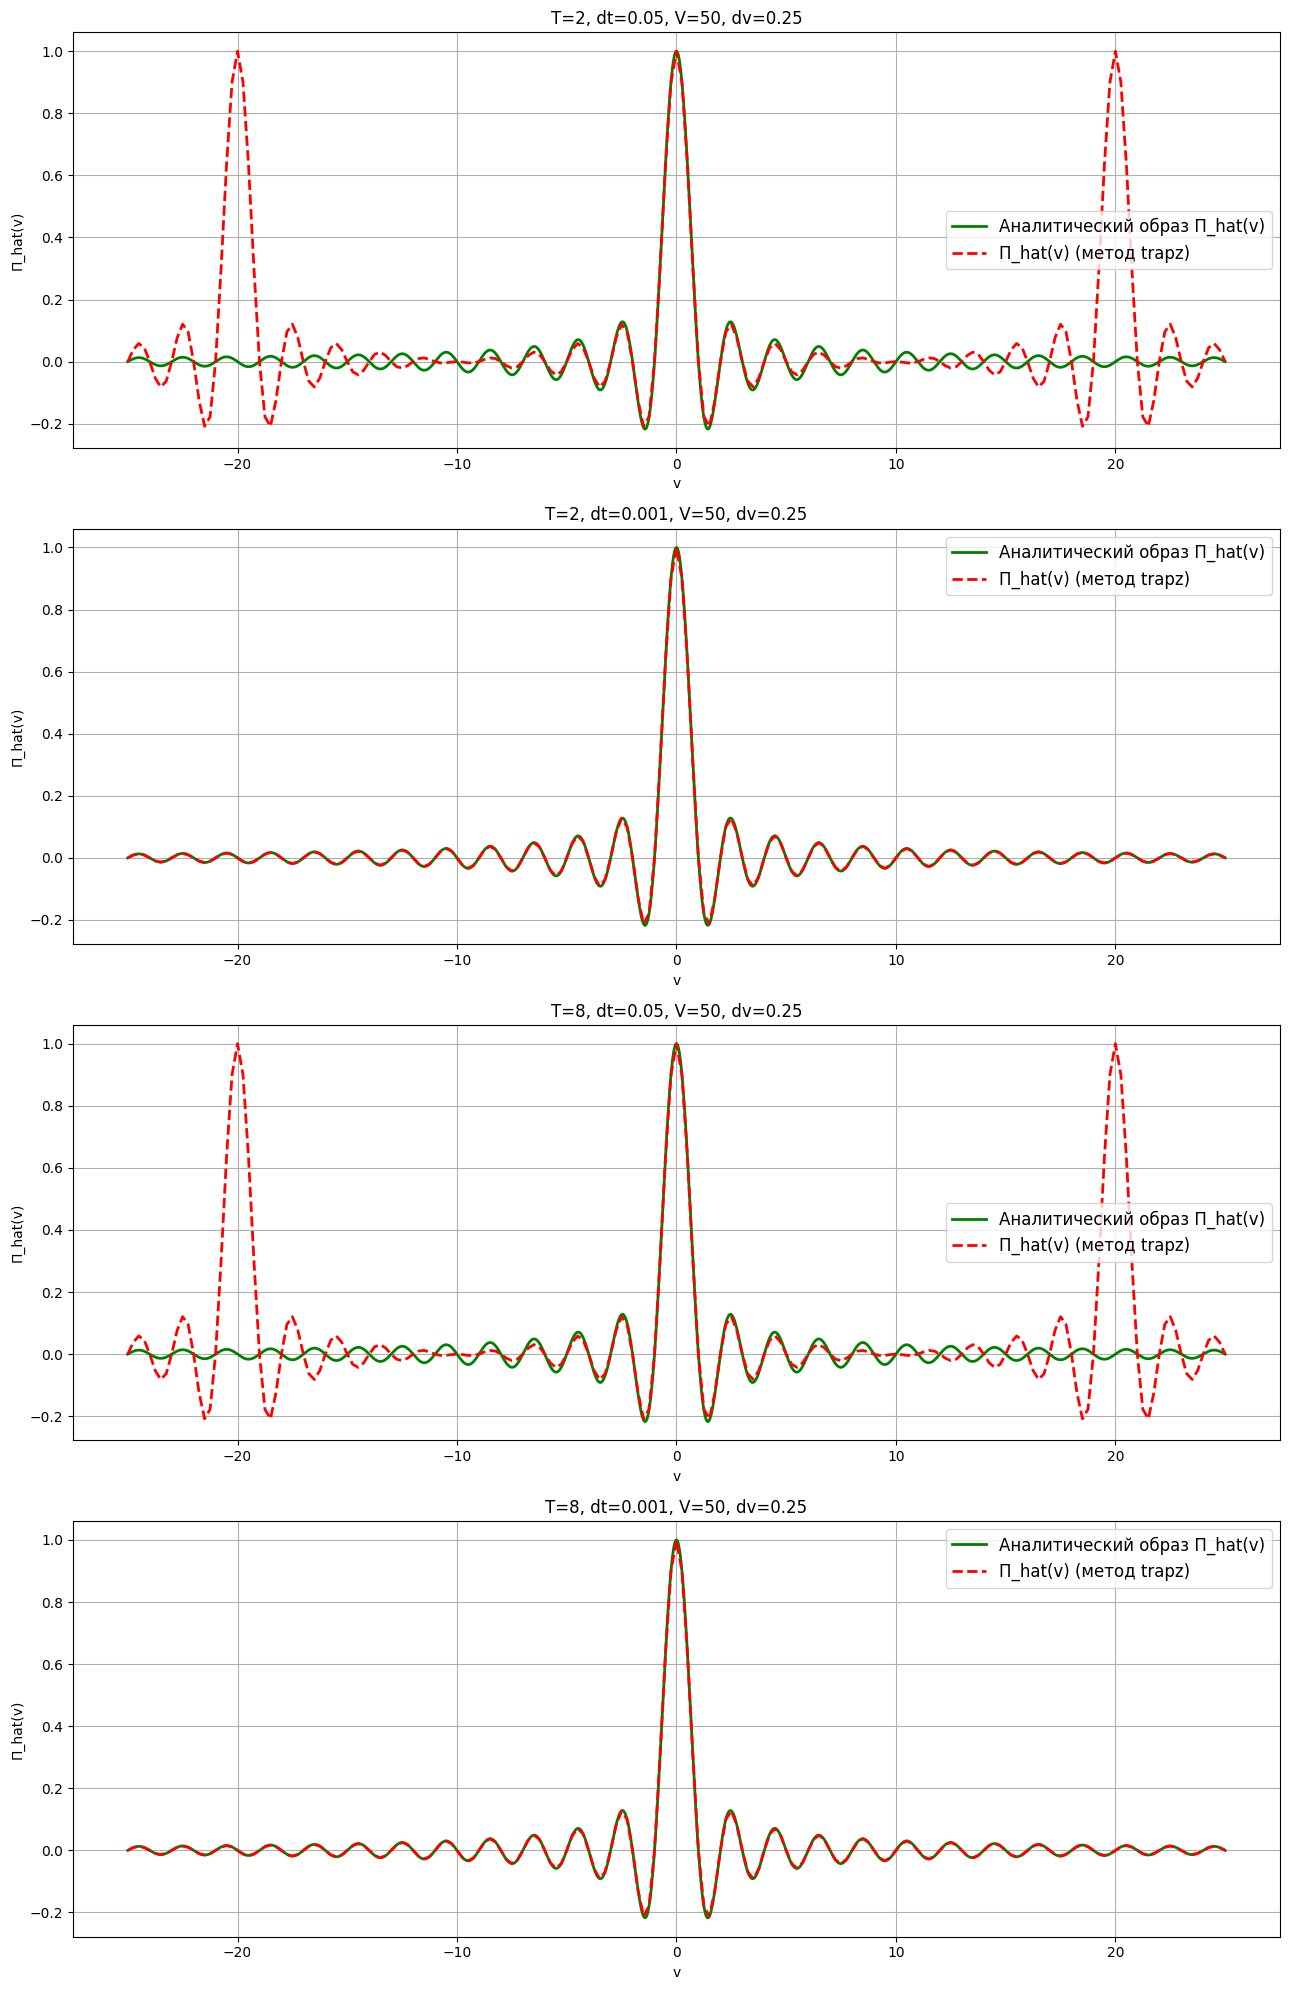

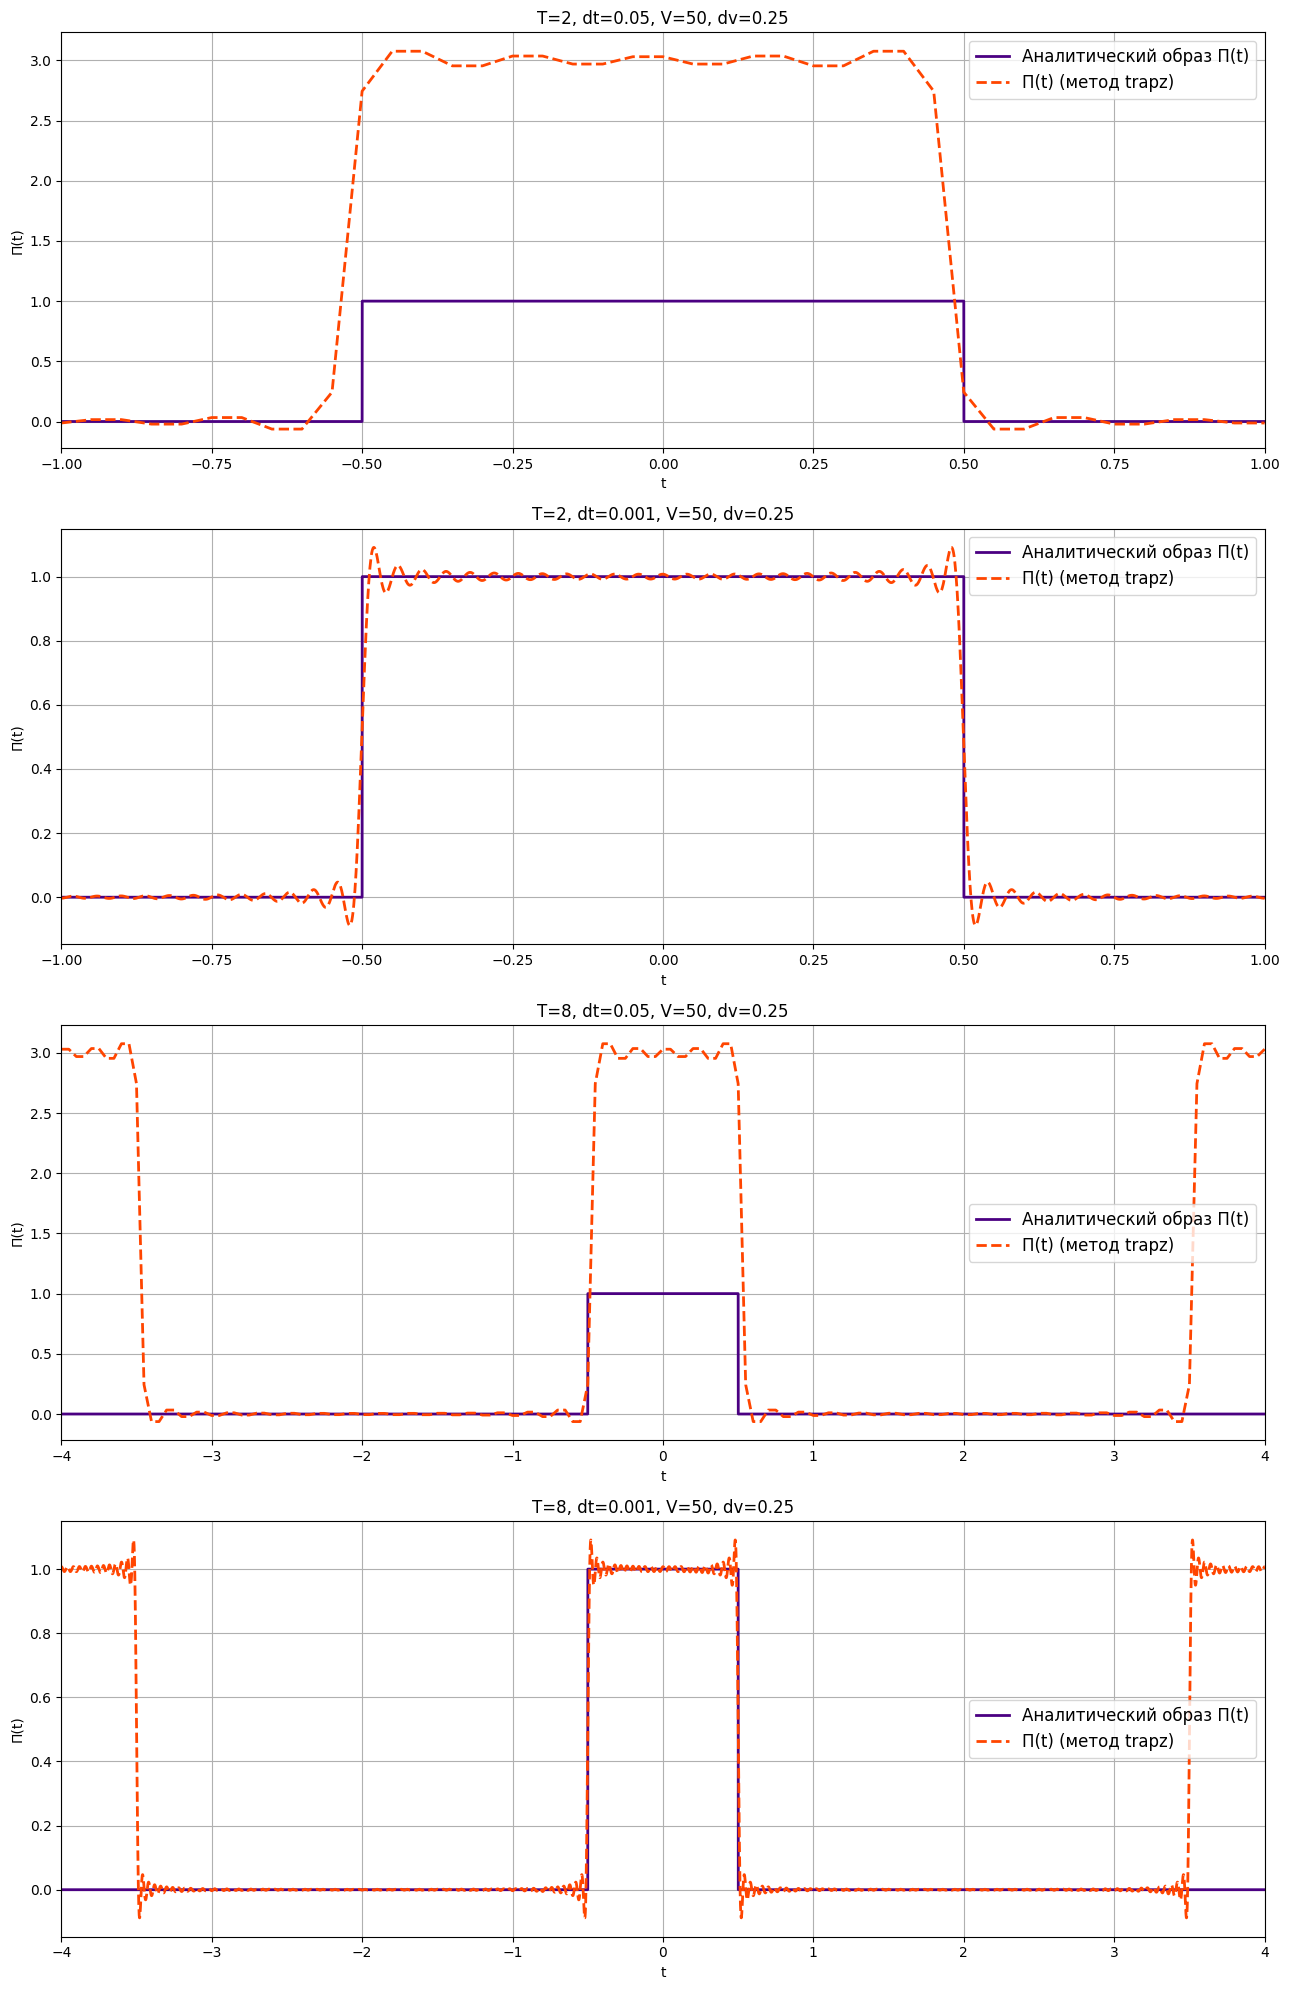

In [7]:
def point_ft(func, t, v):
    return func(t) * np.exp(-2j * np.pi * v * t)
def point_ift(func, v, t):
    return func(v) * np.exp(2j * np.pi * v * t)

T_list = [2, 8]
dt_list = [0.05, 0.001]

chart_V = Chart(4, 1, 13, 20)
chart_T = Chart(4, 1, 13, 20)

for T in T_list:
    for dt in dt_list:
        V = 50
        dv = 0.25
        t_space = np.arange(-T/2, T/2 + dt, dt)
        v_space = np.arange(-V/2, V/2 + dv, dv)
        PI_hat_trapz = [np.trapz(point_ft(rect_func, t_space, v), t_space) for v in v_space]
        @list_func
        def PI_hat_trapz_f(v):
            global v_space
            return PI_hat_trapz[np.where(v_space==v)[0][0]]
        PI_trapz = [np.trapz(point_ift(PI_hat_trapz_f, v_space, t), v_space) for t in t_space]

        plt_g_V = Plot_Group(title=f"T={T}, dt={dt}, V={V}, dv={dv}", x_label="v", y_label="П_hat(v)", legend=True, legend_fontsize="large")
        plt_g_T = Plot_Group(title=f"T={T}, dt={dt}, V={V}, dv={dv}", x_label="t", y_label="П(t)", xlim=(-T/2, T/2), legend=True, legend_fontsize="large")
        plt_g_V.add_plot(Plot(v_rect, PI_hat, "Аналитический образ П_hat(v)", "green", linewidth=2))
        plt_g_V.add_plot(Plot(v_space, PI_hat_trapz, "П_hat(v) (метод trapz)", "red", linewidth=2, linestyle='--'))
        plt_g_T.add_plot(Plot(t_rect, PI, "Аналитический образ П(t)", "indigo", linewidth=2))
        plt_g_T.add_plot(Plot(t_space, PI_trapz, "П(t) (метод trapz)", "orangered", linewidth=2, linestyle='--'))

        chart_V.add_plot_group(plt_g_V)
        chart_T.add_plot_group(plt_g_T)
        del plt_g_V, plt_g_T

chart_V.save_chart(plt_folder, "П_hat(v)_comparison_fix_v", dpi=200)
chart_T.save_chart(plt_folder, "П(t)_comparison_fix_v", dpi=200)

del chart_V, chart_T

/home/ns/ros2_venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ns/ros2_venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


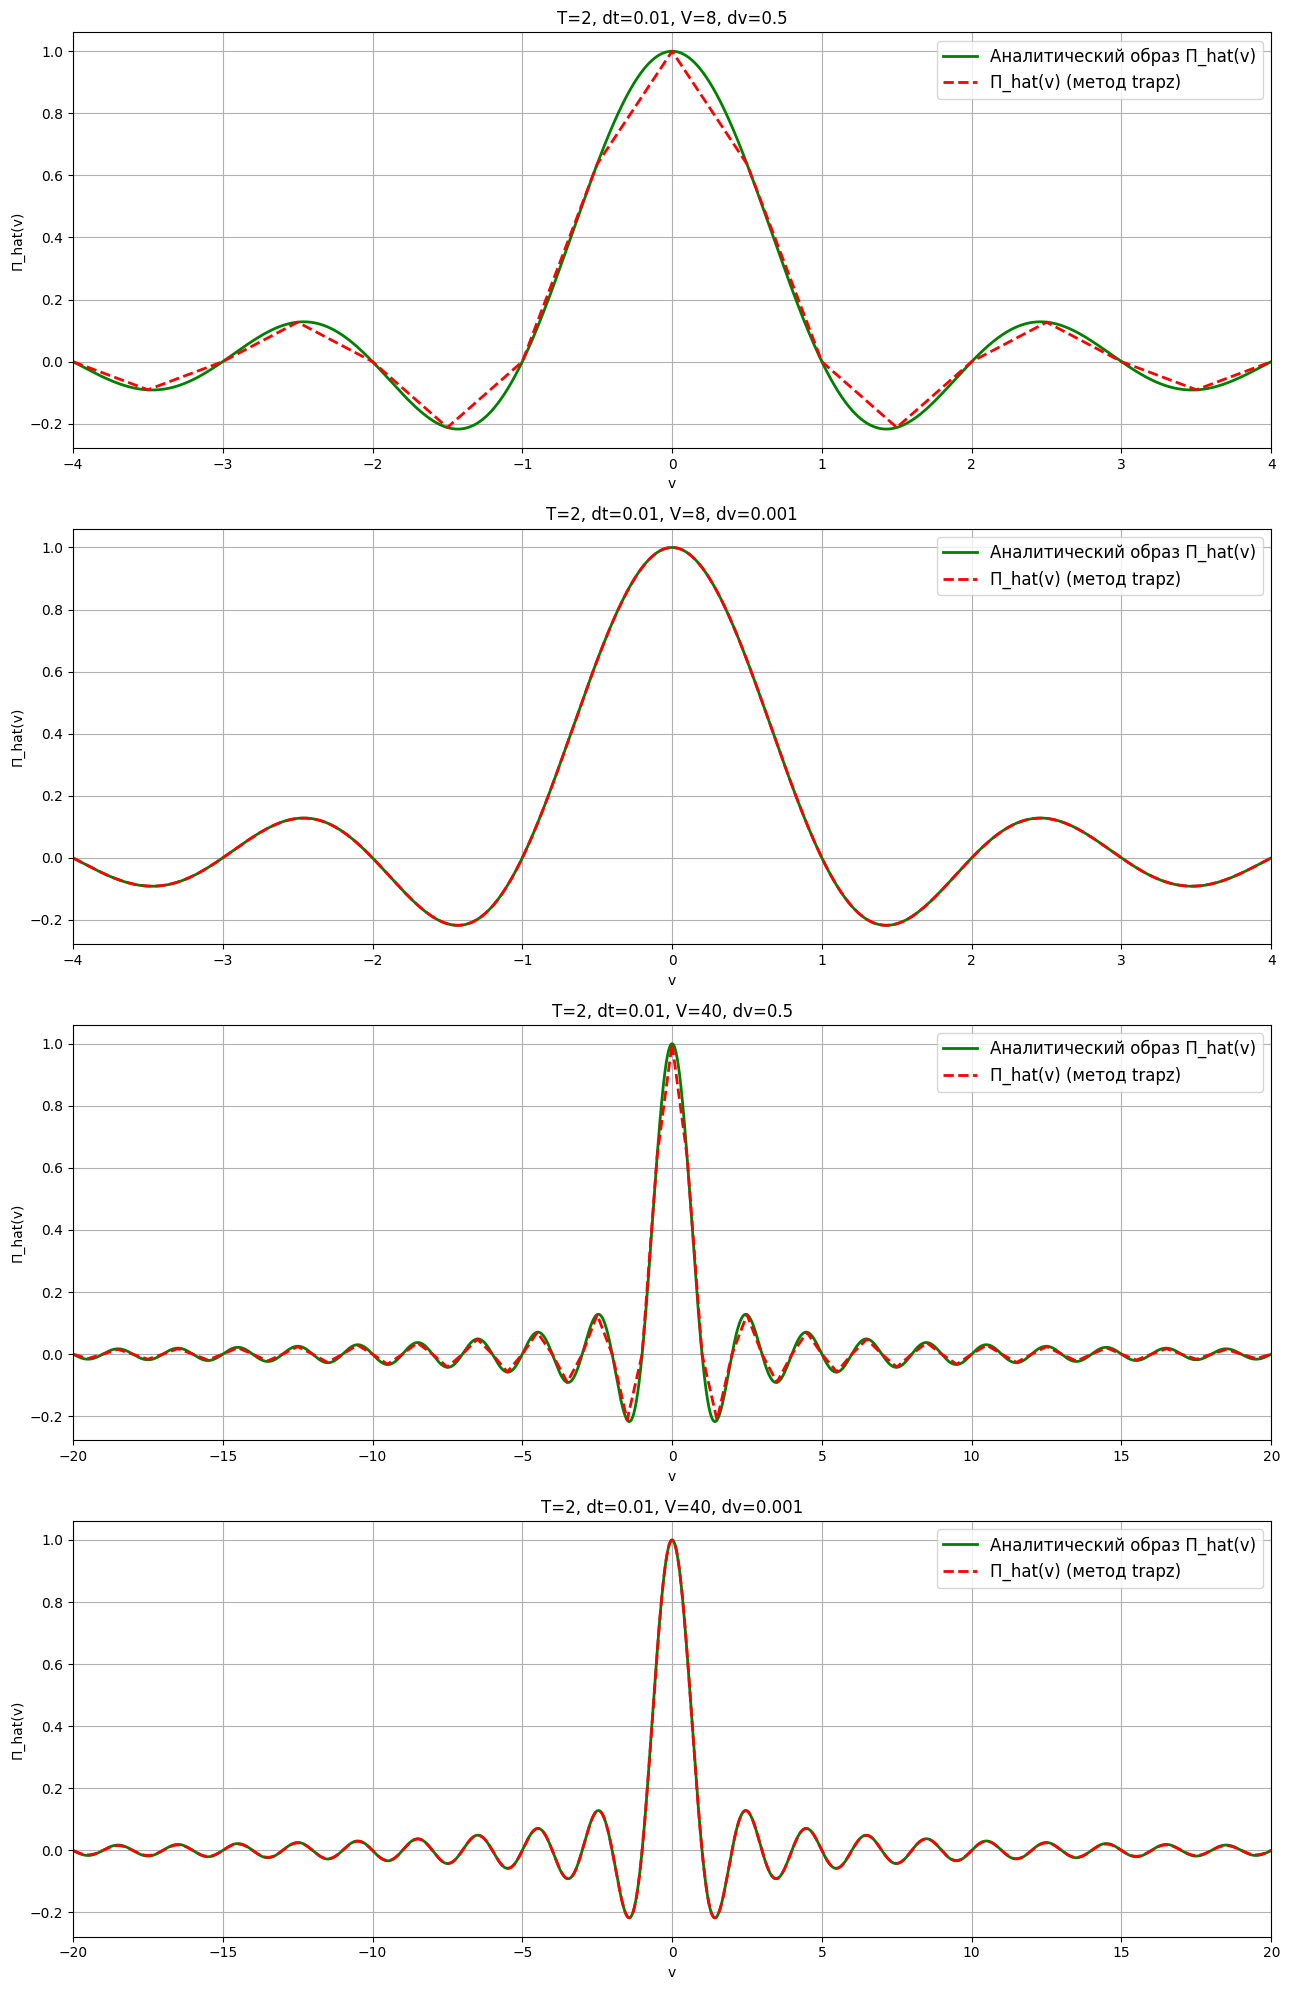

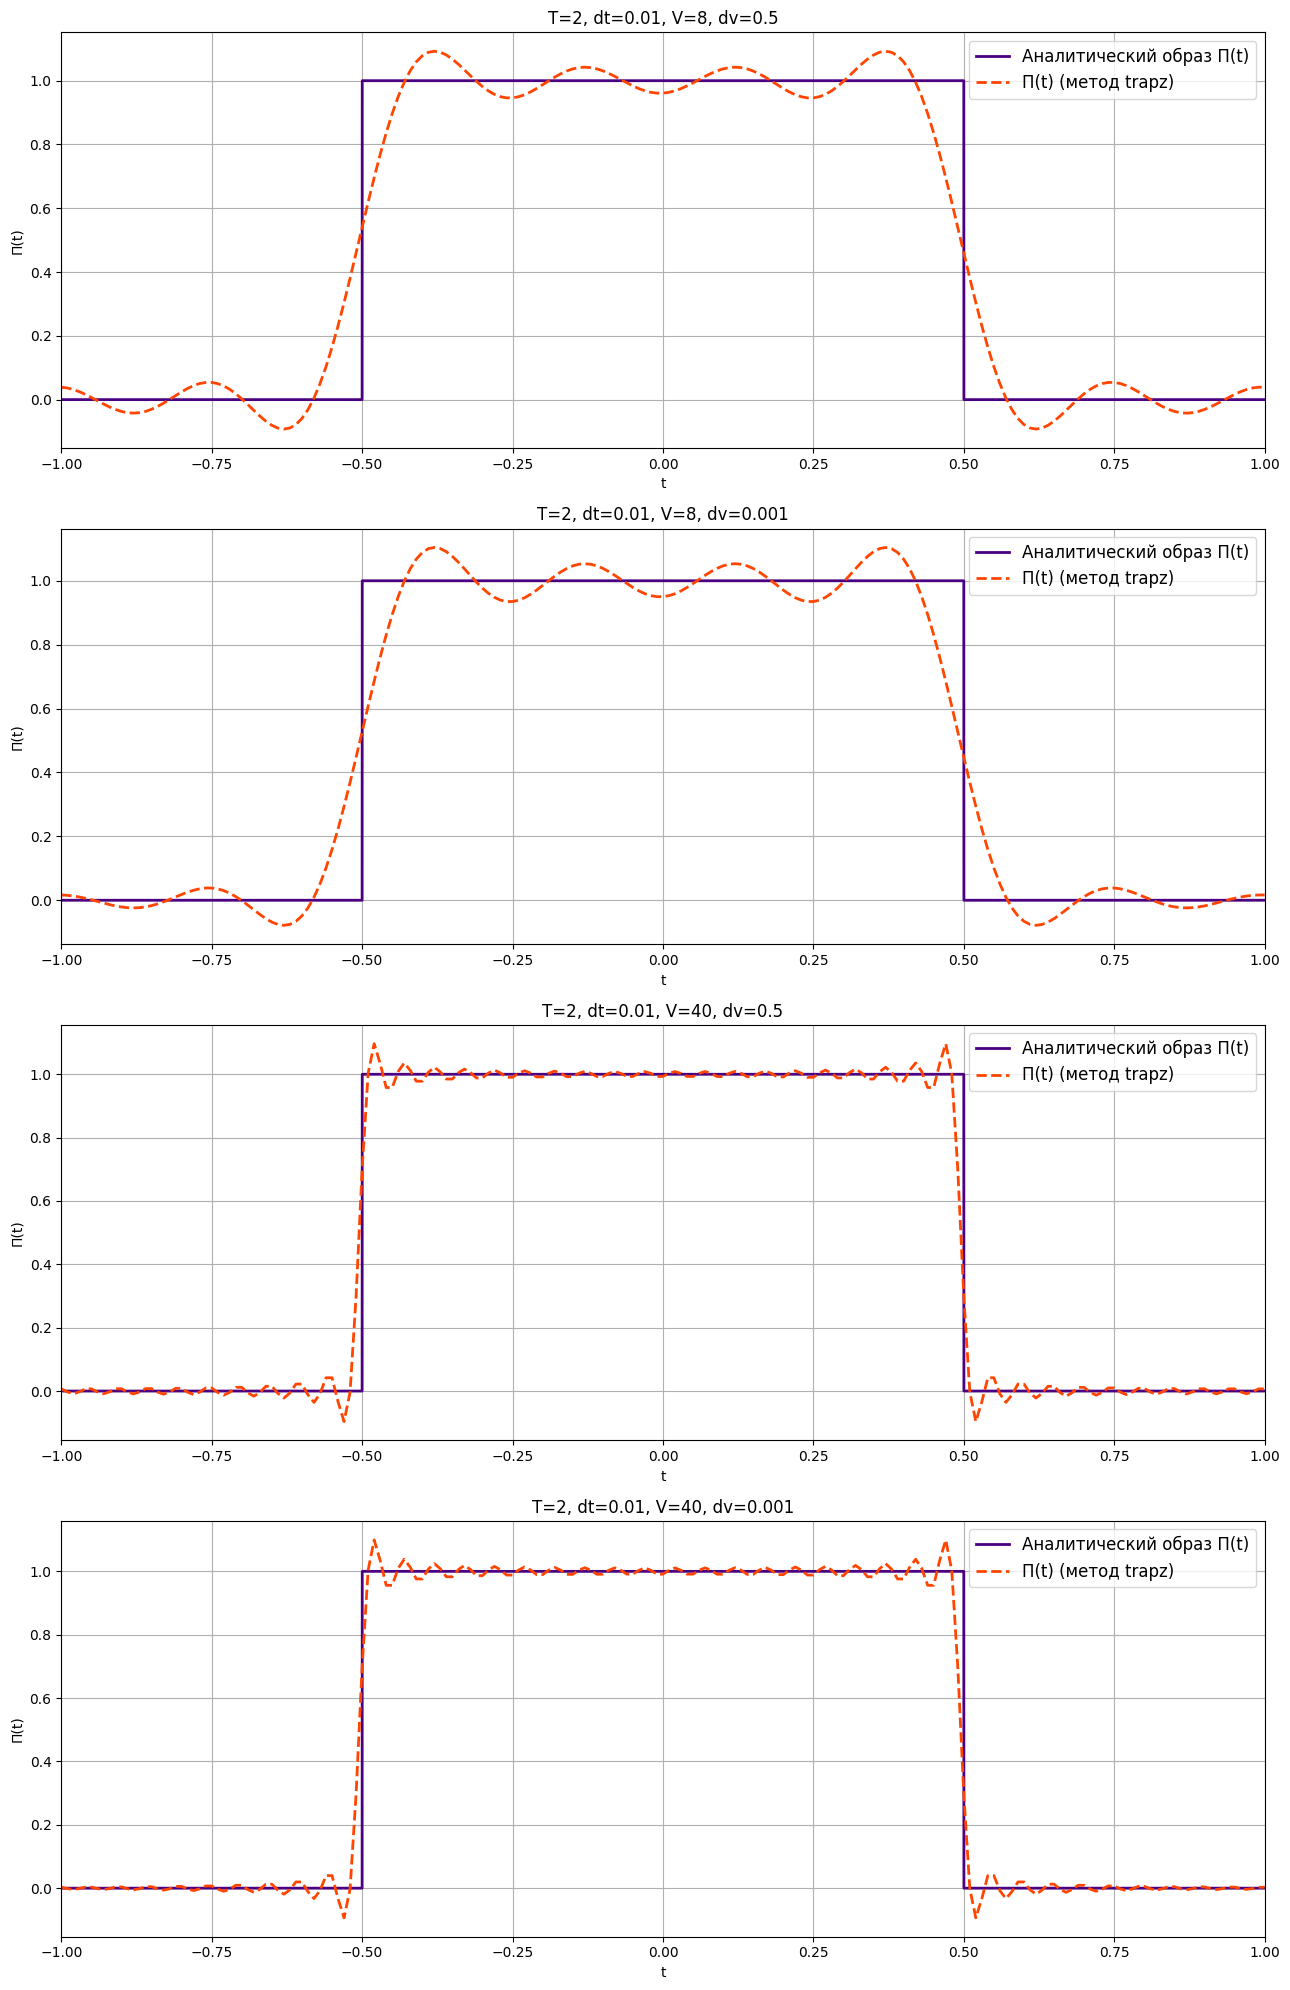

In [8]:
V_list = [8, 40]
dv_list = [0.5, 0.001]

chart_V = Chart(4, 1, 13, 20)
chart_T = Chart(4, 1, 13, 20)

for V in V_list:
    for dv in dv_list:
        T = 2
        dt = 0.01
        t_space = np.arange(-T/2, T/2 + dt, dt)
        v_space = np.arange(-V/2, V/2 + dv, dv)
        PI_hat_trapz = [np.trapz(point_ft(rect_func, t_space, v), t_space) for v in v_space]
        @list_func
        def PI_hat_trapz_f(v):
            global v_space
            return PI_hat_trapz[np.where(v_space==v)[0][0]]
        PI_trapz = [np.trapz(point_ift(PI_hat_trapz_f, v_space, t), v_space) for t in t_space]

        plt_g_V = Plot_Group(title=f"T={T}, dt={dt}, V={V}, dv={dv}", x_label="v", y_label="П_hat(v)", xlim=(-V/2, V/2), legend=True, legend_fontsize="large")
        plt_g_T = Plot_Group(title=f"T={T}, dt={dt}, V={V}, dv={dv}", x_label="t", y_label="П(t)", xlim=(-1, 1), legend=True, legend_fontsize="large")
        plt_g_V.add_plot(Plot(v_rect, PI_hat, "Аналитический образ П_hat(v)", "green", linewidth=2))
        plt_g_V.add_plot(Plot(v_space, PI_hat_trapz, "П_hat(v) (метод trapz)", "red", linewidth=2, linestyle='--'))
        plt_g_T.add_plot(Plot(t_rect, PI, "Аналитический образ П(t)", "indigo", linewidth=2))
        plt_g_T.add_plot(Plot(t_space, PI_trapz, "П(t) (метод trapz)", "orangered", linewidth=2, linestyle='--'))

        chart_V.add_plot_group(plt_g_V)
        chart_T.add_plot_group(plt_g_T)
        del plt_g_V, plt_g_T

chart_V.save_chart(plt_folder, "П_hat(v)_comparison_fix_t", dpi=200)
chart_T.save_chart(plt_folder, "П(t)_comparison_fix_t", dpi=200)

del chart_V, chart_T

# Задание 1.2

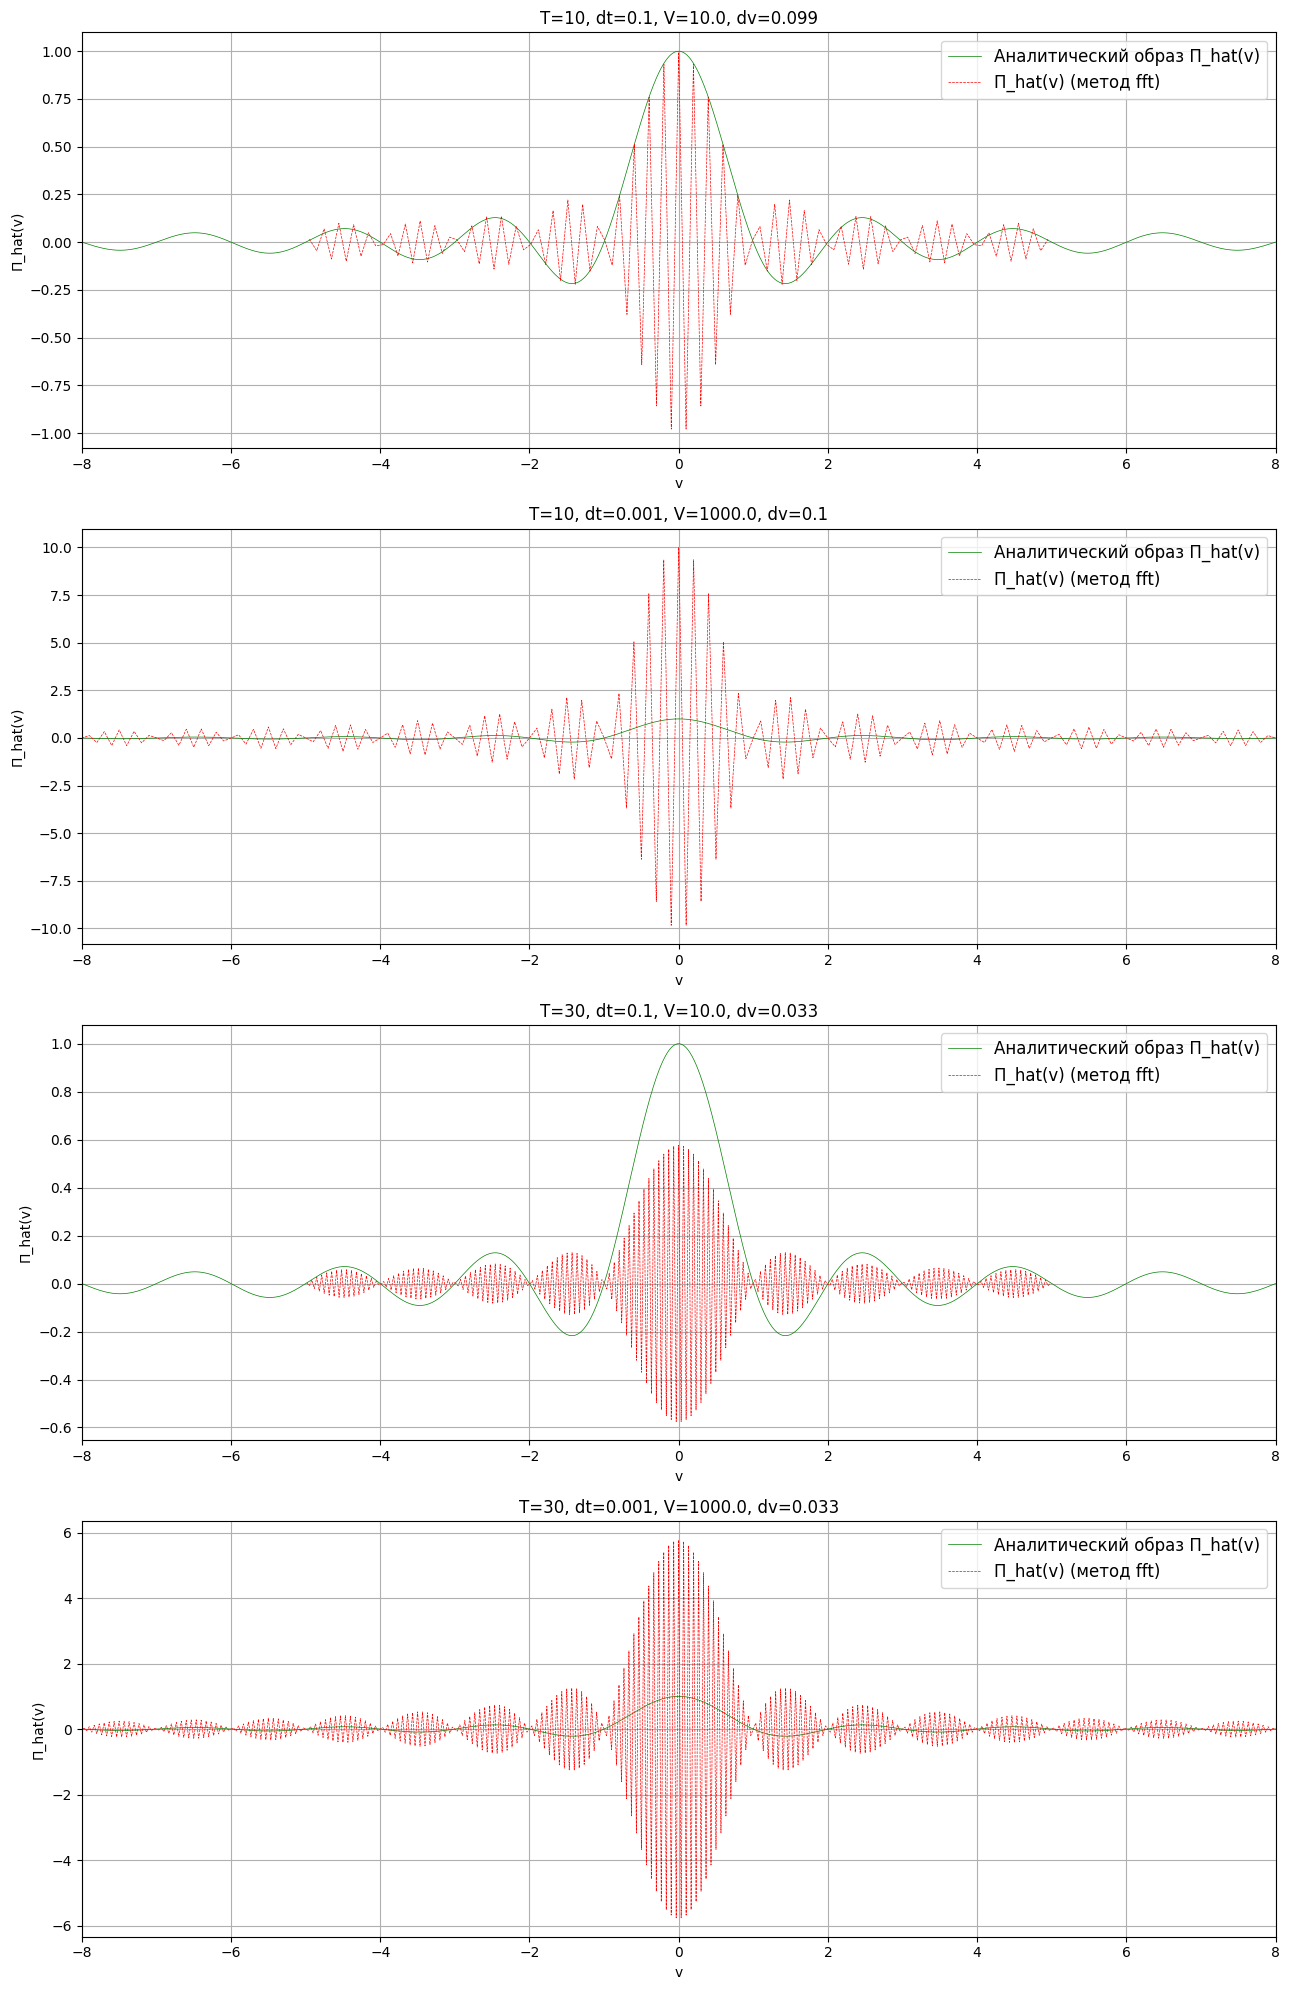

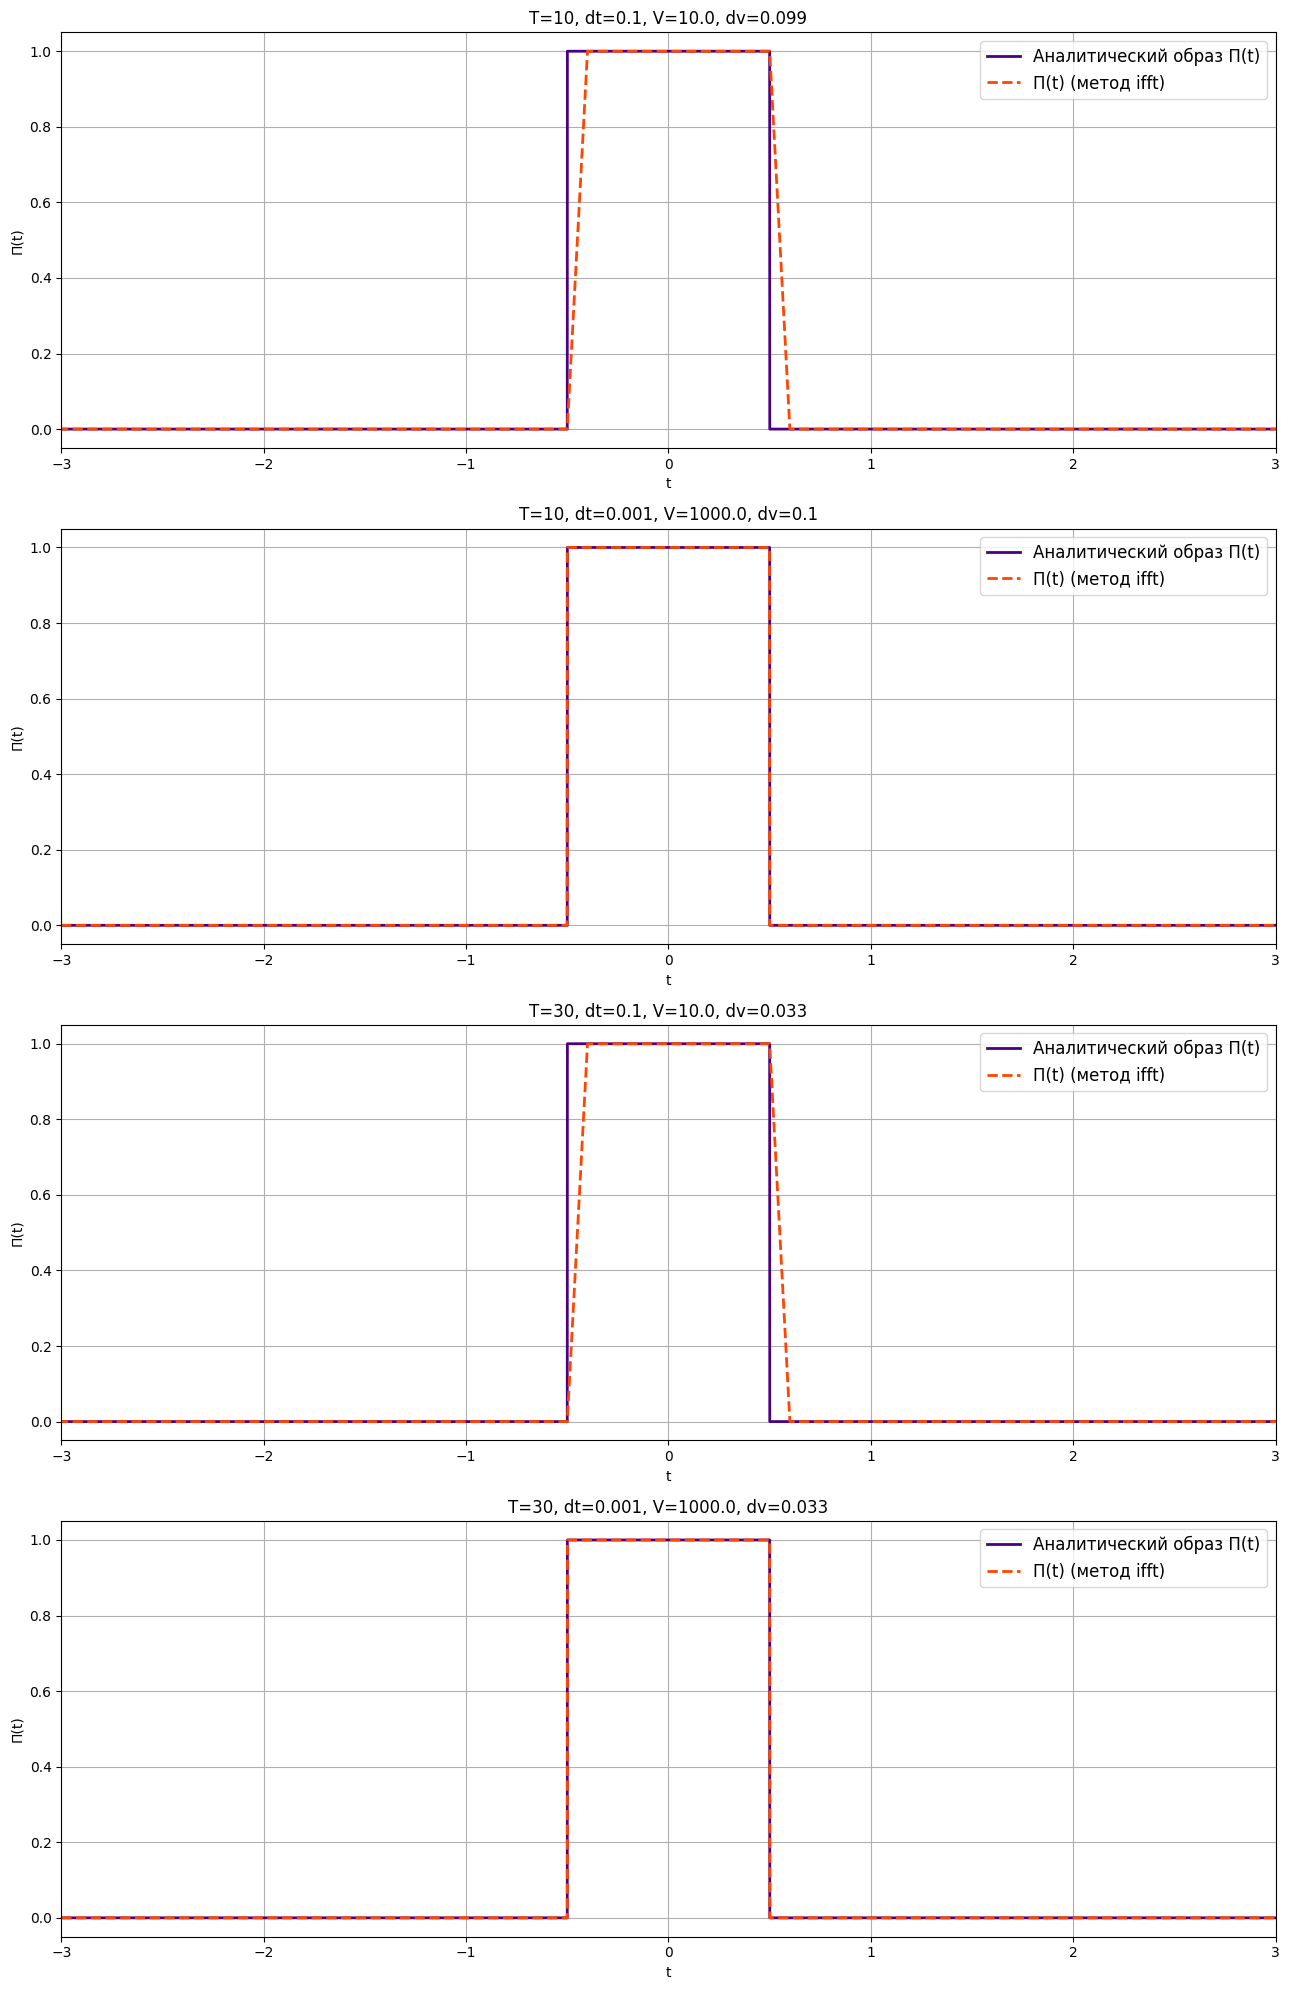

In [9]:
T_list = [10, 30]
dt_list = [0.1, 0.001]

chart_V = Chart(4, 1, 13, 20)
chart_T = Chart(4, 1, 13, 20)

for T in T_list:
    for dt in dt_list:
        t_space = np.arange(-T/2, T/2 + dt, dt)
        N = len(t_space)
        dv = 1 / (N * dt)
        V = 1 / dt
        v_space = fftshift(fftfreq(N, dt))

        PI_1 = rect_func(t_space)
        PI_hat_fft = fftshift(fft(PI_1, norm='ortho'))
        PI_fft = ifft(ifftshift(PI_hat_fft), norm='ortho')

        plt_g_V = Plot_Group(title=f"T={T}, dt={dt}, V={V}, dv={round(dv, 3)}", x_label="v", y_label="П_hat(v)", xlim=(-8, 8), legend=True, legend_fontsize="large")
        plt_g_T = Plot_Group(title=f"T={T}, dt={dt}, V={V}, dv={round(dv, 3)}", x_label="t", y_label="П(t)", xlim=(-3, 3), legend=True, legend_fontsize="large")
        plt_g_V.add_plot(Plot(v_rect, PI_hat, "Аналитический образ П_hat(v)", "green", linewidth=0.5))
        plt_g_V.add_plot(Plot(v_space, np.real(PI_hat_fft), "П_hat(v) (метод fft)", "red", linewidth=0.5, linestyle='--'))
        plt_g_T.add_plot(Plot(t_rect, PI, "Аналитический образ П(t)", "indigo", linewidth=2))
        plt_g_T.add_plot(Plot(t_space, np.real(PI_fft), "П(t) (метод ifft)", "orangered", linewidth=2, linestyle='--'))

        chart_V.add_plot_group(plt_g_V)
        chart_T.add_plot_group(plt_g_T)
        del plt_g_V, plt_g_T

chart_V.save_chart(plt_folder, "П_hat(v)_comparison_fft_fix_v", dpi=200)
chart_T.save_chart(plt_folder, "П(t)_comparison_fft_fix_v", dpi=200)

del chart_V, chart_T

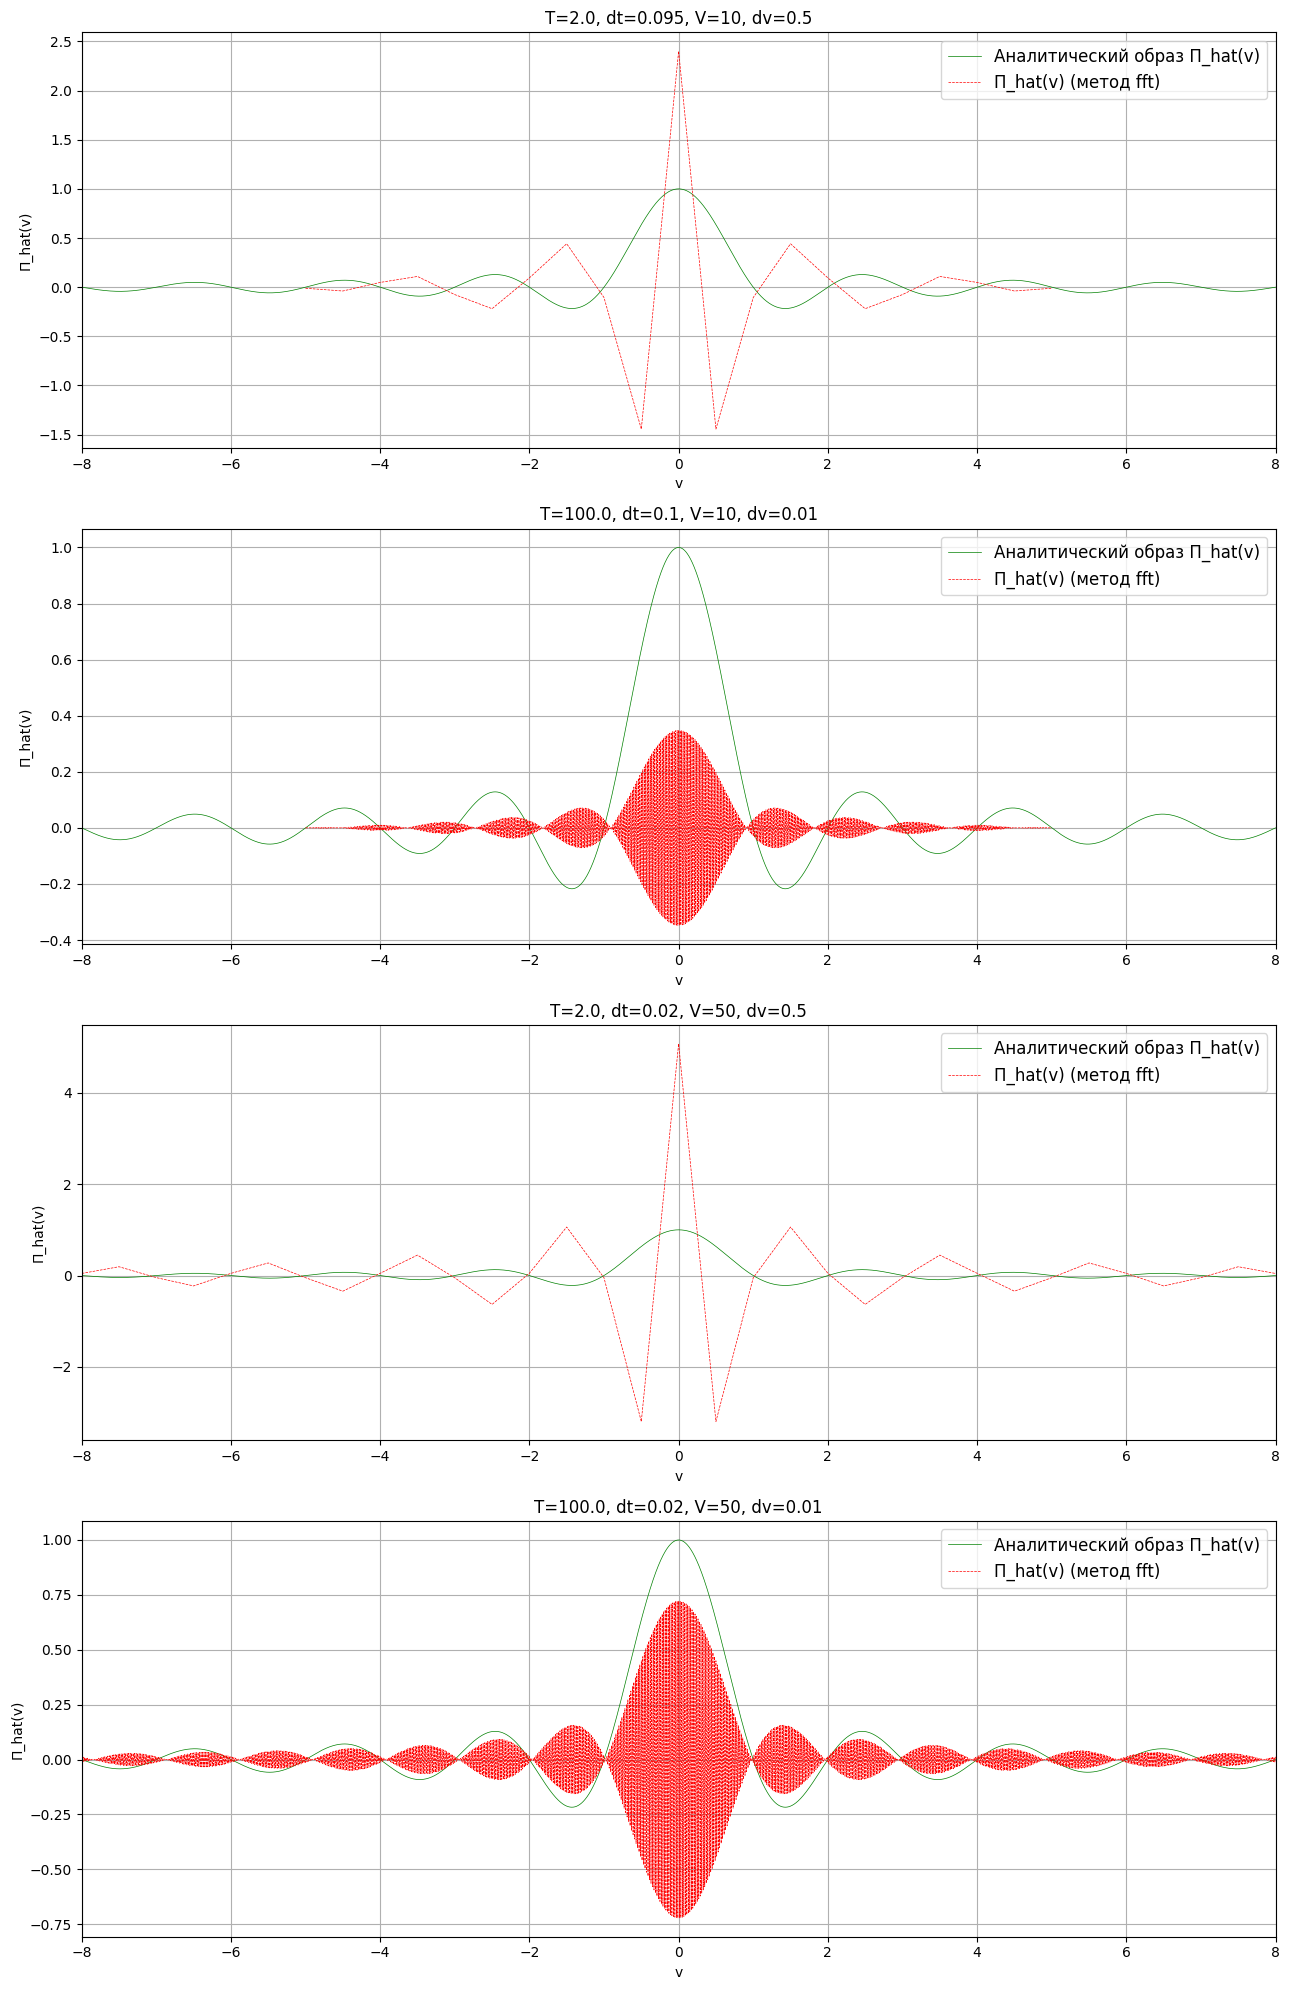

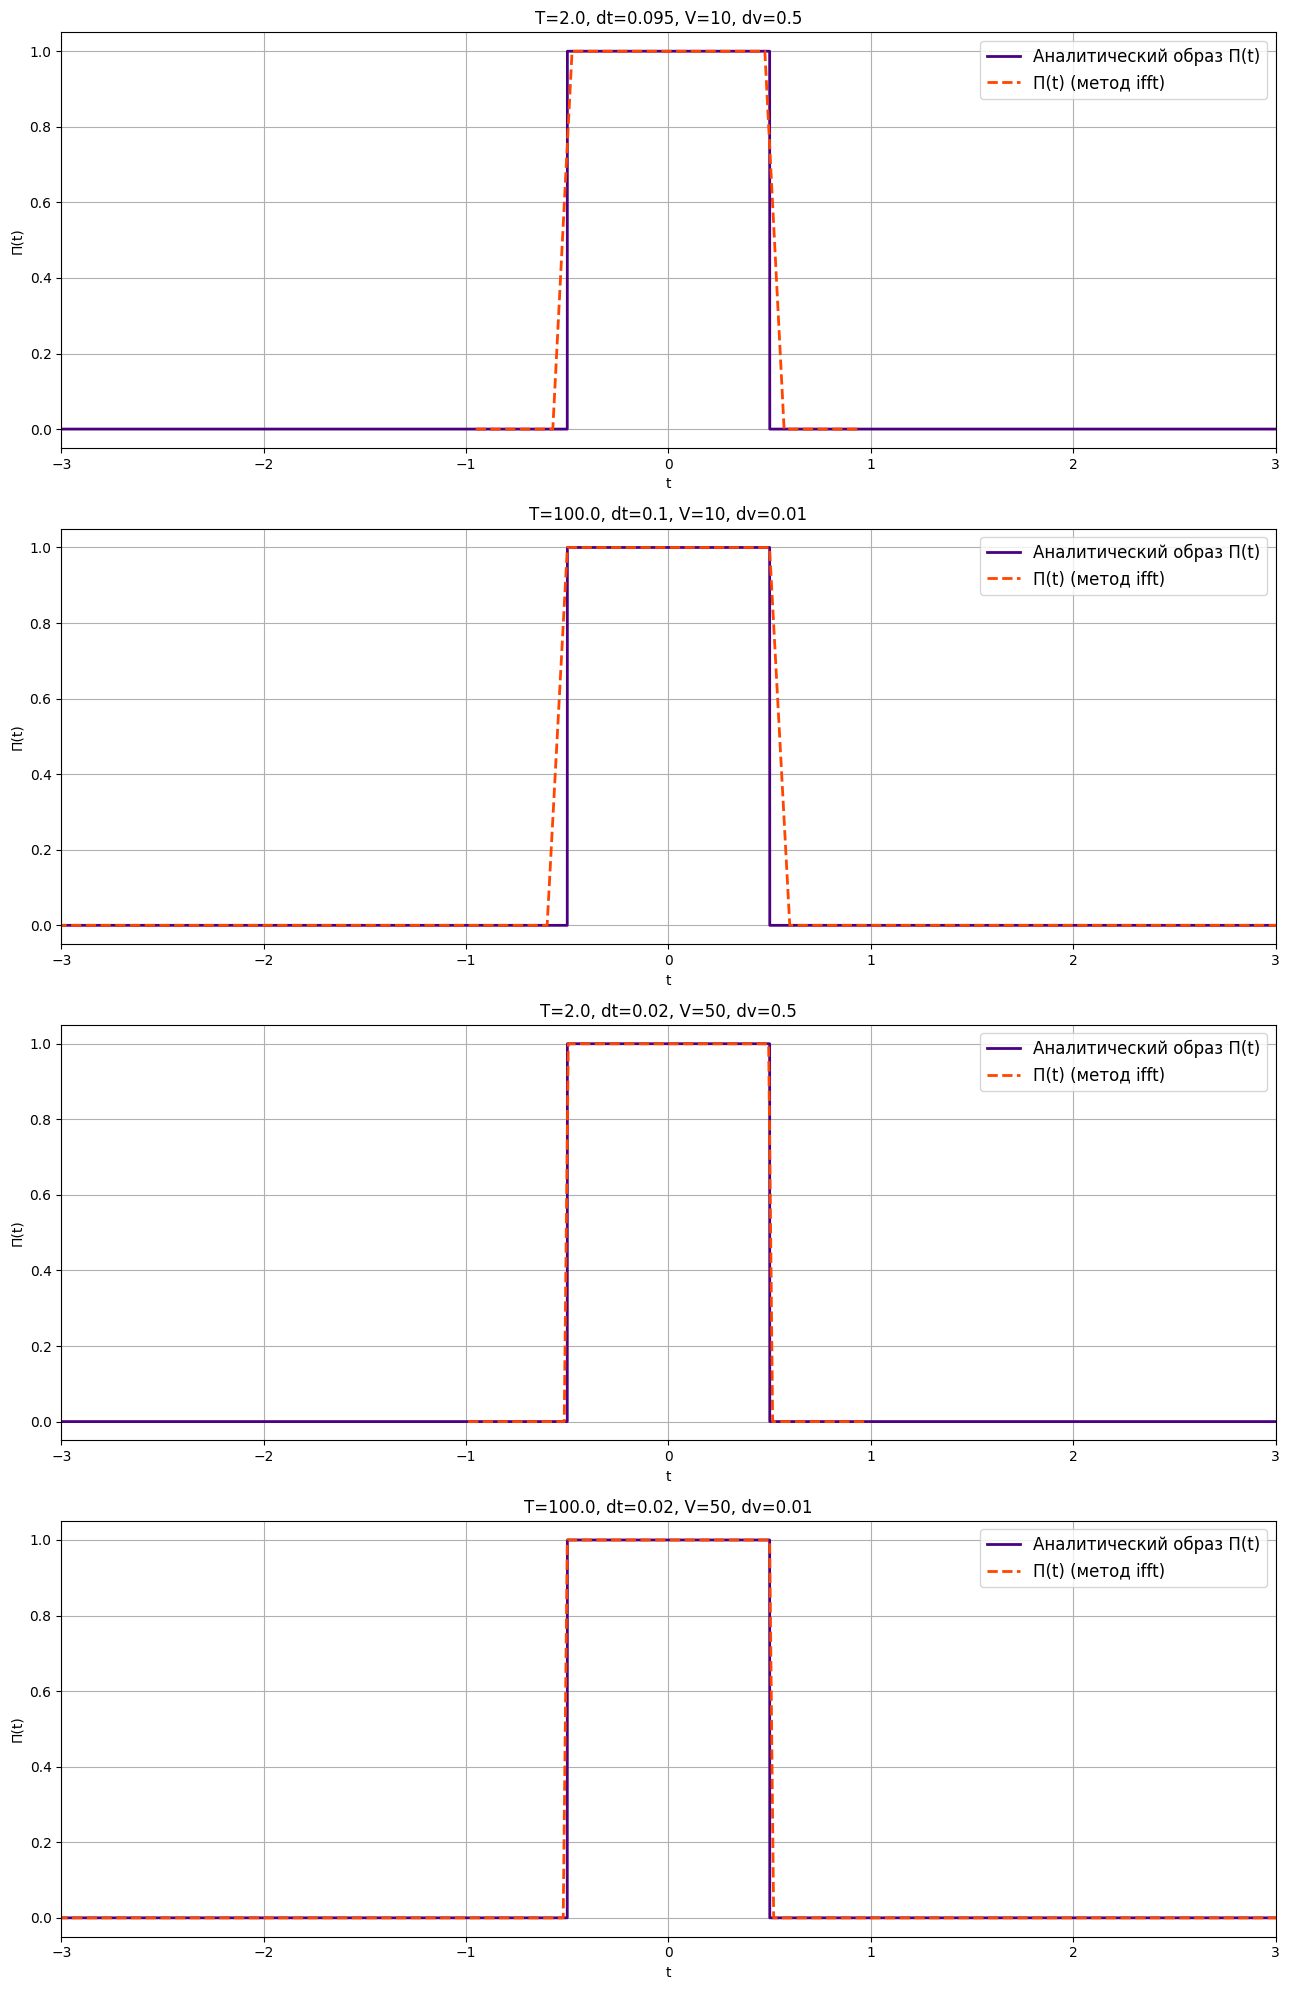

In [10]:
V_list = [10, 50]
dv_list = [0.5, 0.01]

chart_V = Chart(4, 1, 13, 20)
chart_T = Chart(4, 1, 13, 20)

for V in V_list:
    for dv in dv_list:
        v_space = np.arange(-V/2, V/2 + dv, dv)
        N = len(v_space)
        dt = 1 / (N * dv)
        T = 1 / dv
        t_space = fftshift(fftfreq(N, dv))

        PI_1 = rect_func(t_space)
        PI_hat_fft = fftshift(fft(PI_1, norm='ortho'))
        PI_fft = ifft(ifftshift(PI_hat_fft), norm='ortho')

        plt_g_V = Plot_Group(title=f"T={T}, dt={round(dt, 3)}, V={V}, dv={dv}", x_label="v", y_label="П_hat(v)", xlim=(-8, 8), legend=True, legend_fontsize="large")
        plt_g_T = Plot_Group(title=f"T={T}, dt={round(dt, 3)}, V={V}, dv={dv}", x_label="t", y_label="П(t)", xlim=(-3, 3), legend=True, legend_fontsize="large")
        plt_g_V.add_plot(Plot(v_rect, PI_hat, "Аналитический образ П_hat(v)", "green", linewidth=0.5))
        plt_g_V.add_plot(Plot(v_space, np.real(PI_hat_fft), "П_hat(v) (метод fft)", "red", linewidth=0.5, linestyle='--'))
        plt_g_T.add_plot(Plot(t_rect, PI, "Аналитический образ П(t)", "indigo", linewidth=2))
        plt_g_T.add_plot(Plot(t_space, np.real(PI_fft), "П(t) (метод ifft)", "orangered", linewidth=2, linestyle='--'))

        chart_V.add_plot_group(plt_g_V)
        chart_T.add_plot_group(plt_g_T)
        del plt_g_V, plt_g_T

chart_V.save_chart(plt_folder, "П_hat(v)_comparison_fft_fix_t", dpi=200)
chart_T.save_chart(plt_folder, "П(t)_comparison_fft_fix_t", dpi=200)

del chart_V, chart_T

Сравнение $O(N^2)$ и $O(N\log(N))$

/tmp/ipykernel_38445/577117435.py:3: RuntimeWarning: divide by zero encountered in log
  NlogN = x * np.log(x)
/tmp/ipykernel_38445/577117435.py:3: RuntimeWarning: invalid value encountered in multiply
  NlogN = x * np.log(x)


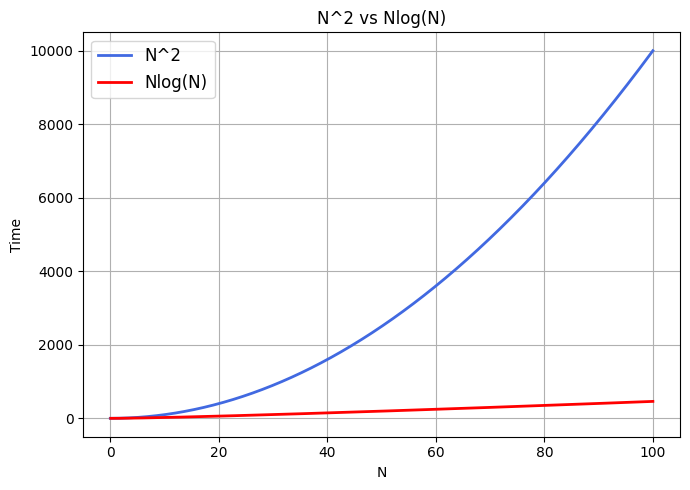

In [11]:
x = np.linspace(0, 10 ** 2, 1000)
N2 = x ** 2
NlogN = x * np.log(x)
chart = Chart()
plt_g = Plot_Group(title="N^2 vs Nlog(N)", x_label="N", y_label="Time", legend=True, legend_fontsize="large")
plt_g.add_plot(Plot(x, N2, "N^2", linewidth=2, color="royalblue"))
plt_g.add_plot(Plot(x, NlogN, "Nlog(N)", linewidth=2, color="red"))
chart.add_plot_group(plt_g)
chart.save_chart(plt_folder, "N2_NlogN", dpi=200)
del plt_g, chart

# Задание 1.4

In [12]:
def smart_fft(func, T, dt):
    t_space = np.arange(-T/2, T/2, dt)
    N = len(t_space)
    v_space = fftshift(fftfreq(N, dt))
    y_space = func(t_space)
    c_m = dt * np.exp(1j * np.pi * v_space * T)
    fft_func = fftshift(c_m * fft(y_space))
    return fft_func, v_space

def smart_ifft(y_space, v_space, dt):
    N = len(v_space)
    T = N * dt
    t_space = fftshift(fftfreq(N, dt))
    c_m = dt * np.exp(1j * np.pi * v_space * T)
    fft_func = ifft(ifftshift(y_space) / c_m)
    return fft_func

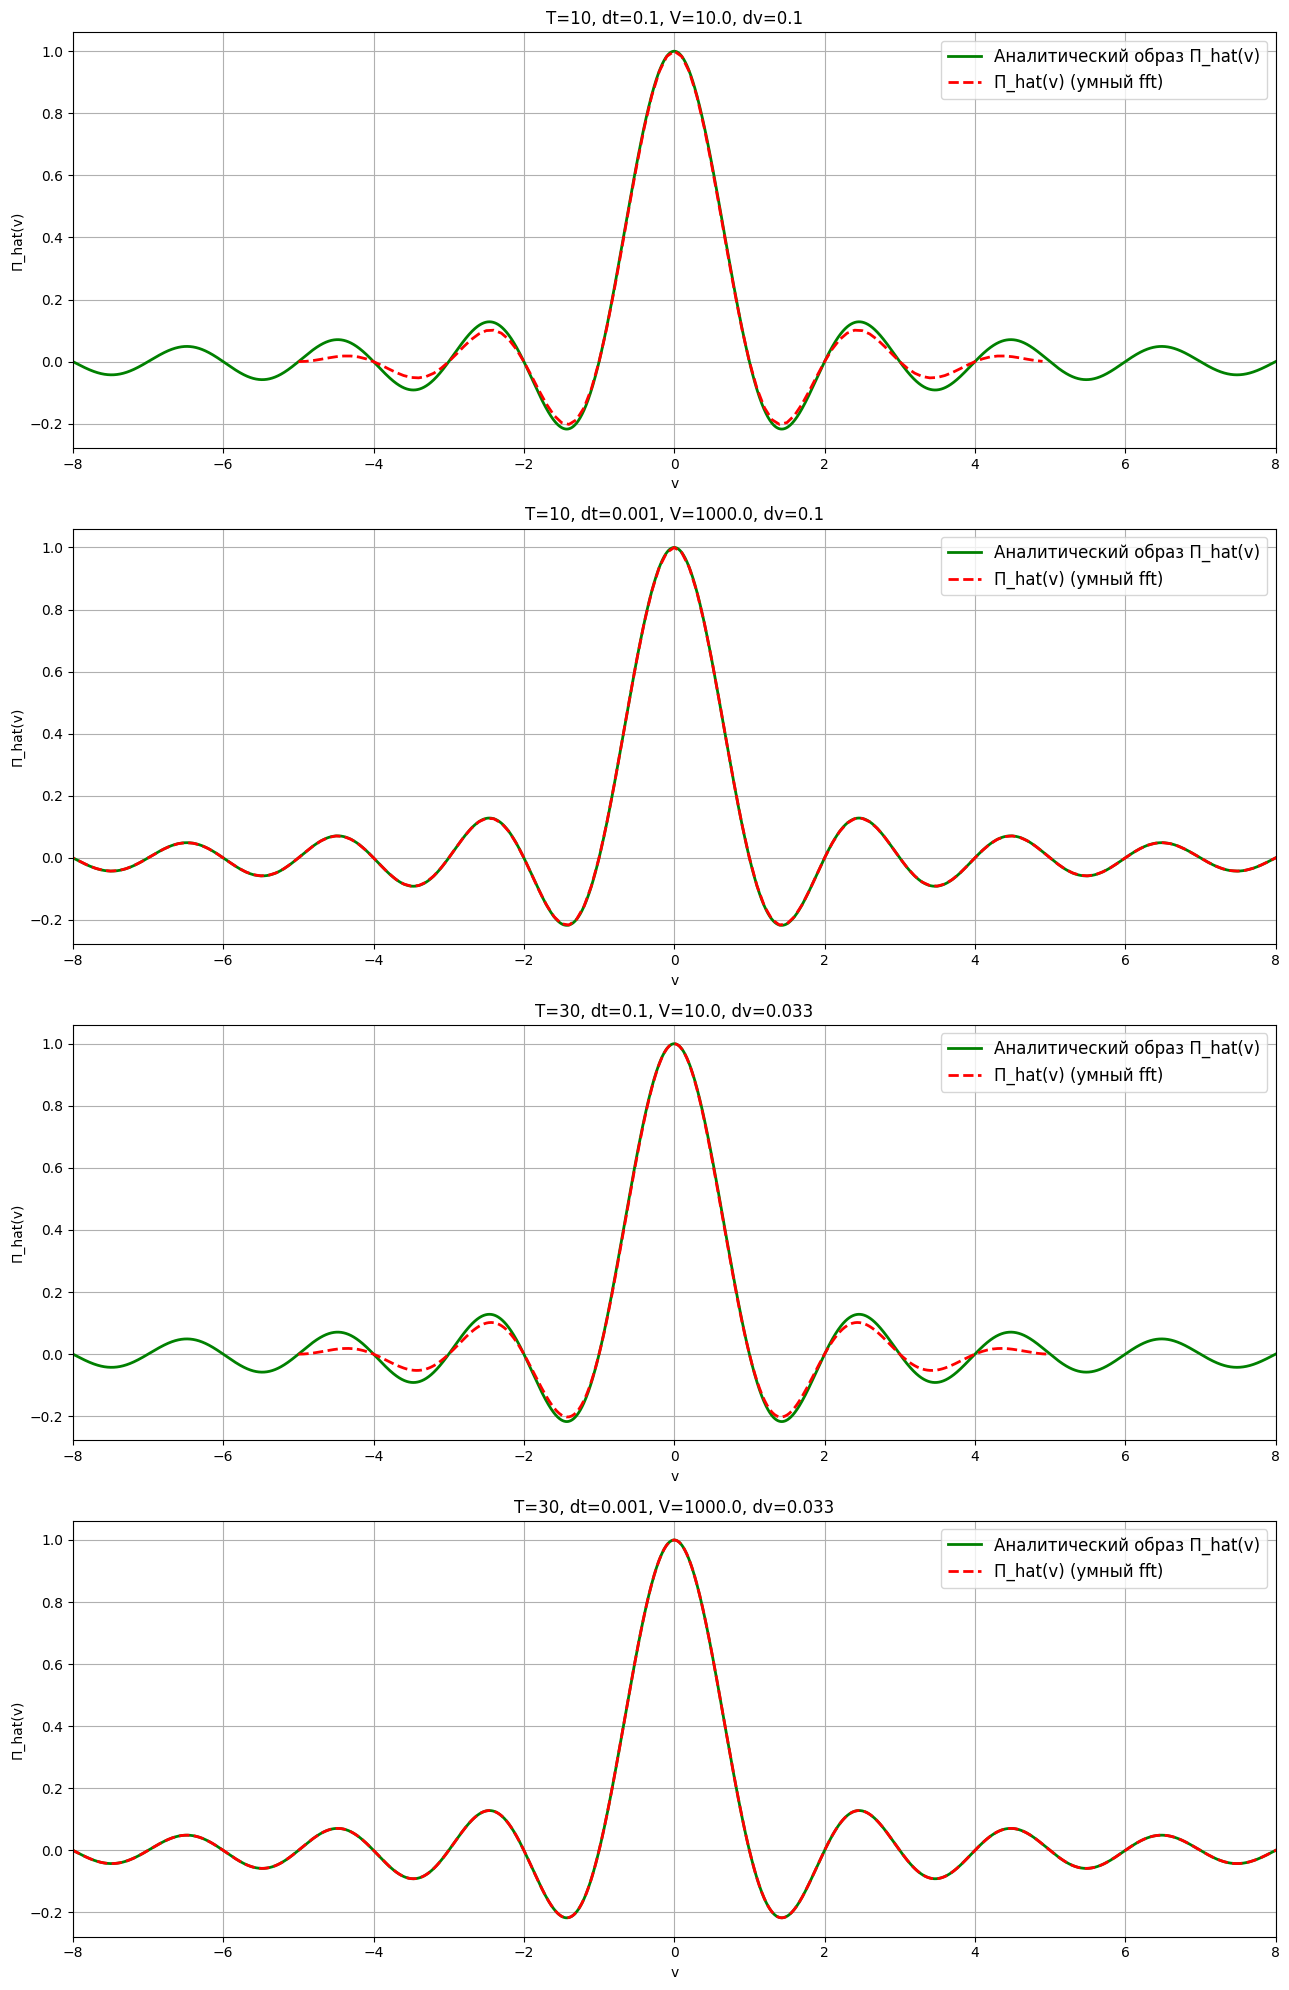

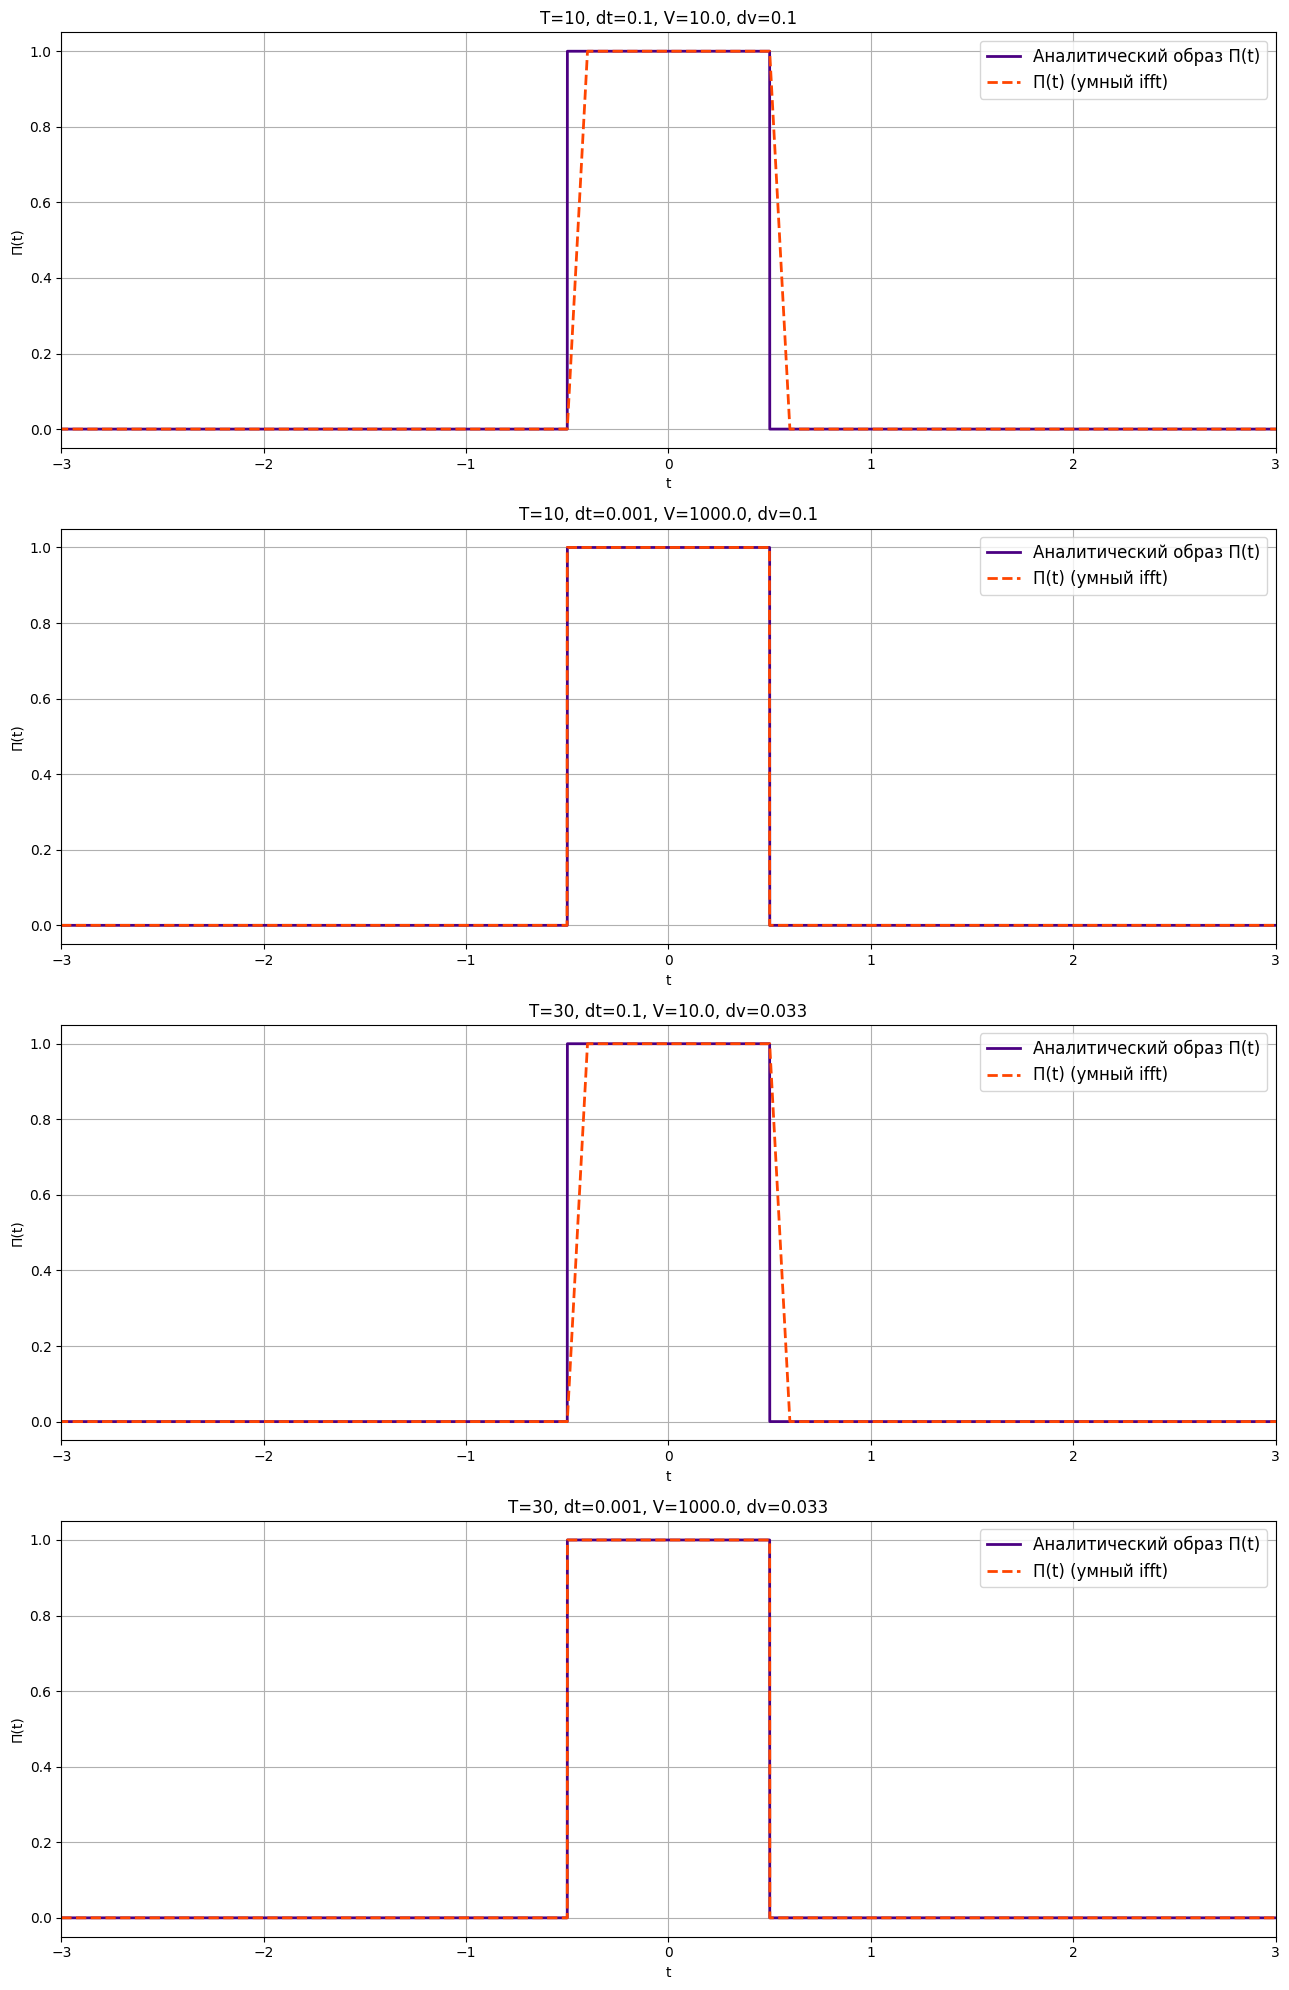

In [13]:
T_list = [10, 30]
dt_list = [0.1, 0.001]

chart_V = Chart(4, 1, 13, 20)
chart_T = Chart(4, 1, 13, 20)

for T in T_list:
    for dt in dt_list:
        t_space = np.arange(-T/2, T/2, dt)
        N = len(t_space)
        dv = 1 / (N * dt)
        V = 1 / dt

        PI_1 = rect_func(t_space)
        PI_hat_sfft, v_space = smart_fft(rect_func, T, dt)
        PI_sfft = smart_ifft(PI_hat_sfft, v_space, dt)

        plt_g_V = Plot_Group(title=f"T={T}, dt={dt}, V={V}, dv={round(dv, 3)}", x_label="v", y_label="П_hat(v)", xlim=(-8, 8), legend=True, legend_fontsize="large")
        plt_g_T = Plot_Group(title=f"T={T}, dt={dt}, V={V}, dv={round(dv, 3)}", x_label="t", y_label="П(t)", xlim=(-3, 3), legend=True, legend_fontsize="large")
        plt_g_V.add_plot(Plot(v_rect, PI_hat, "Аналитический образ П_hat(v)", "green", linewidth=2))
        plt_g_V.add_plot(Plot(v_space, np.real(PI_hat_sfft), "П_hat(v) (умный fft)", "red", linewidth=2, linestyle='--'))
        plt_g_T.add_plot(Plot(t_rect, PI, "Аналитический образ П(t)", "indigo", linewidth=2))
        plt_g_T.add_plot(Plot(t_space, np.real(PI_sfft), "П(t) (умный ifft)", "orangered", linewidth=2, linestyle='--'))

        chart_V.add_plot_group(plt_g_V)
        chart_T.add_plot_group(plt_g_T)
        del plt_g_V, plt_g_T

chart_V.save_chart(plt_folder, "П_hat(v)_comparison_sfft", dpi=200)
chart_T.save_chart(plt_folder, "П(t)_comparison_sfft", dpi=200)

del chart_V, chart_T

# Сравнение методов

/home/ns/ros2_venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ns/ros2_venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


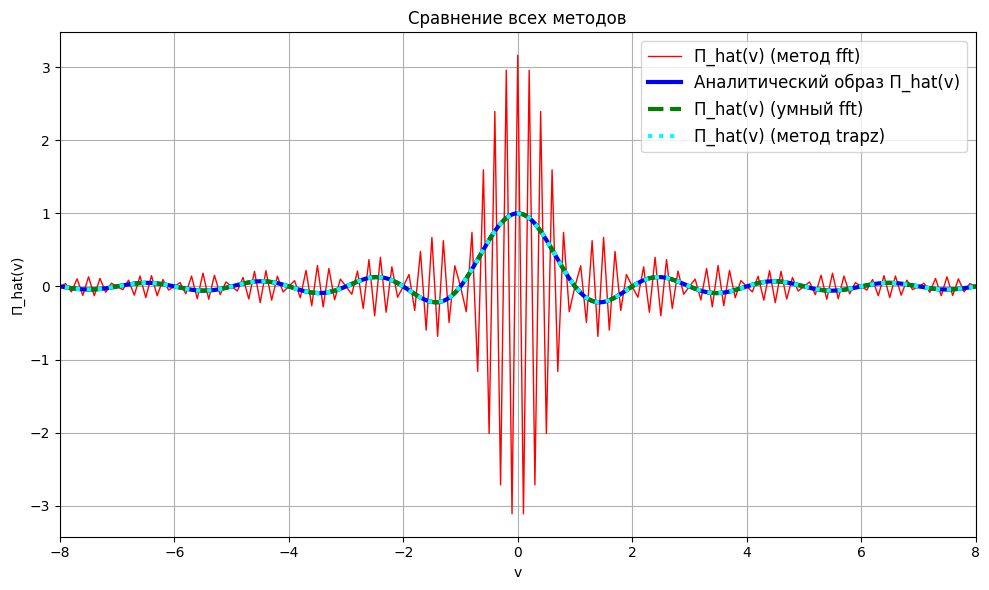

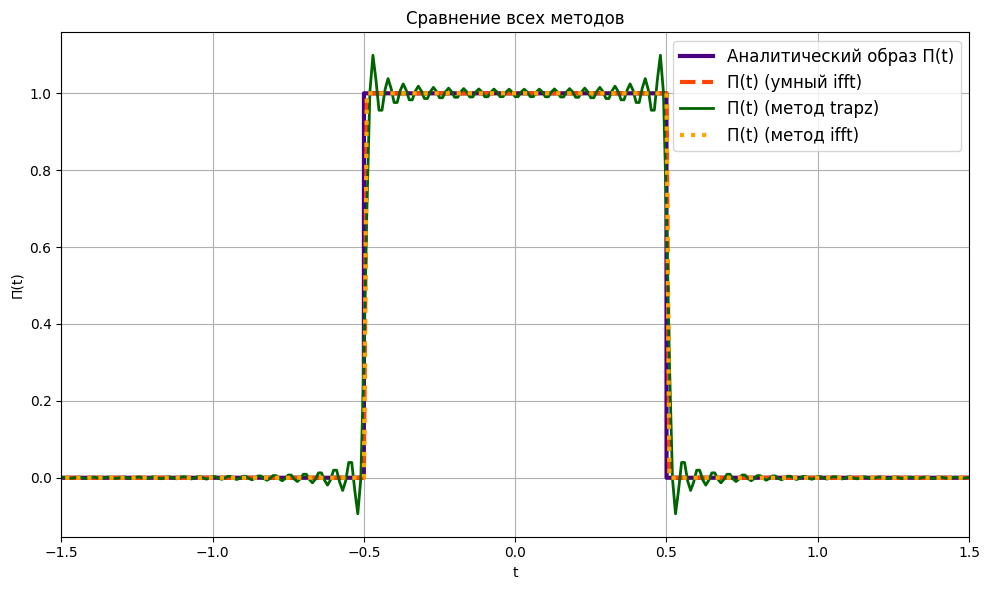

In [14]:
T = 10
dt = 0.01

chart_V = Chart(1, 1, 10, 6)
chart_T = Chart(1, 1, 10, 6)

t_space = np.arange(-T/2, T/2, dt)
N = len(t_space)
dv = 1 / (N * dt)
V = 1 / dt

PI_1 = rect_func(t_space)
PI_hat_sfft, v_space = smart_fft(rect_func, T, dt)
PI_sfft = smart_ifft(PI_hat_sfft, v_space, dt)

v_space_trapz = np.arange(-20, 20.1, 0.1)
PI_hat_trapz = [np.trapz(point_ft(rect_func, t_space, v), t_space) for v in v_space_trapz]
@list_func
def PI_hat_trapz_f(v):
    global v_space_trapz
    return PI_hat_trapz[np.where(v_space_trapz==v)[0][0]]
PI_trapz = [np.trapz(point_ift(PI_hat_trapz_f, v_space_trapz, t), v_space_trapz) for t in t_space]

PI_hat_fft = fftshift(fft(PI_1, norm='ortho'))
PI_fft = ifft(ifftshift(PI_hat_fft), norm='ortho')

plt_g_V = Plot_Group(title=f"Сравнение всех методов", x_label="v", y_label="П_hat(v)", xlim=(-8, 8), legend=True, legend_fontsize="large")
plt_g_T = Plot_Group(title=f"Сравнение всех методов", x_label="t", y_label="П(t)", xlim=(-1.5, 1.5), legend=True, legend_fontsize="large")

plt_g_V.add_plot(Plot(v_space, np.real(PI_hat_fft), "П_hat(v) (метод fft)", "red", linewidth=1, linestyle='-'))
plt_g_V.add_plot(Plot(v_rect, PI_hat, "Аналитический образ П_hat(v)", "blue", linewidth=3, linestyle='-'))
plt_g_V.add_plot(Plot(v_space, np.real(PI_hat_sfft), "П_hat(v) (умный fft)", "green", linewidth=3, linestyle='--'))
plt_g_V.add_plot(Plot(v_space_trapz, PI_hat_trapz, "П_hat(v) (метод trapz)", "cyan", linewidth=3, linestyle=':'))

plt_g_T.add_plot(Plot(t_rect, PI, "Аналитический образ П(t)", "indigo", linewidth=3))
plt_g_T.add_plot(Plot(t_space, np.real(PI_sfft), "П(t) (умный ifft)", "orangered", linewidth=3, linestyle='--'))
plt_g_T.add_plot(Plot(t_space, PI_trapz, "П(t) (метод trapz)", "darkgreen", linewidth=2, linestyle='-'))
plt_g_T.add_plot(Plot(t_space, np.real(PI_fft), "П(t) (метод ifft)", "orange", linewidth=3, linestyle=':'))

chart_V.add_plot_group(plt_g_V)
chart_T.add_plot_group(plt_g_T)
del plt_g_V, plt_g_T

chart_V.save_chart(plt_folder, "П_hat(v)_comparison_all", dpi=200)
chart_T.save_chart(plt_folder, "П(t)_comparison_all", dpi=200)

del chart_V, chart_T

# Задание 2

In [15]:
@list_func
def y1(t):
    return 3 * np.sin(4 * t + np.pi) + 2 * np.sin(7 * t + 1)

@list_func
def y2(t):
    arg = 6 * t
    return np.sinc(arg)

#### Функция $y_1$

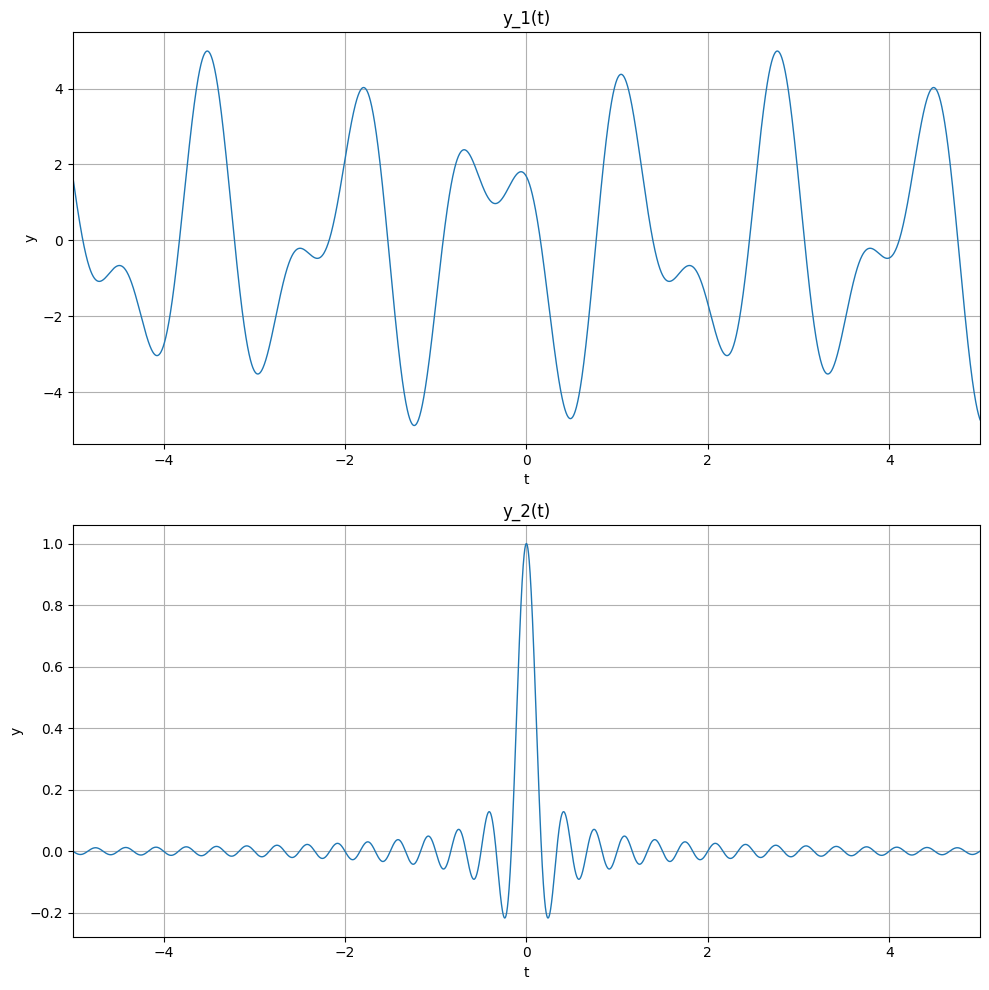

In [16]:
x = np.linspace(-100.0, 100.0, 10**5)
y1_cont = y1(x)
y2_cont = y2(x)

chart = Chart(2, 1, 10, 10)
plt_g = Plot_Group("y_1(t)", "t", "y", xlim=(-5, 5))
plt_g.add_plot(Plot(x, y1_cont, "y_1(t)"))
chart.add_plot_group(plt_g)
del plt_g
plt_g = Plot_Group("y_2(t)", "t", "y", xlim=(-5, 5))
plt_g.add_plot(Plot(x, y2_cont, "y_2(t)"))
chart.add_plot_group(plt_g)
chart.save_chart(plt_folder, "y1_cont", dpi=200)
del plt_g, chart

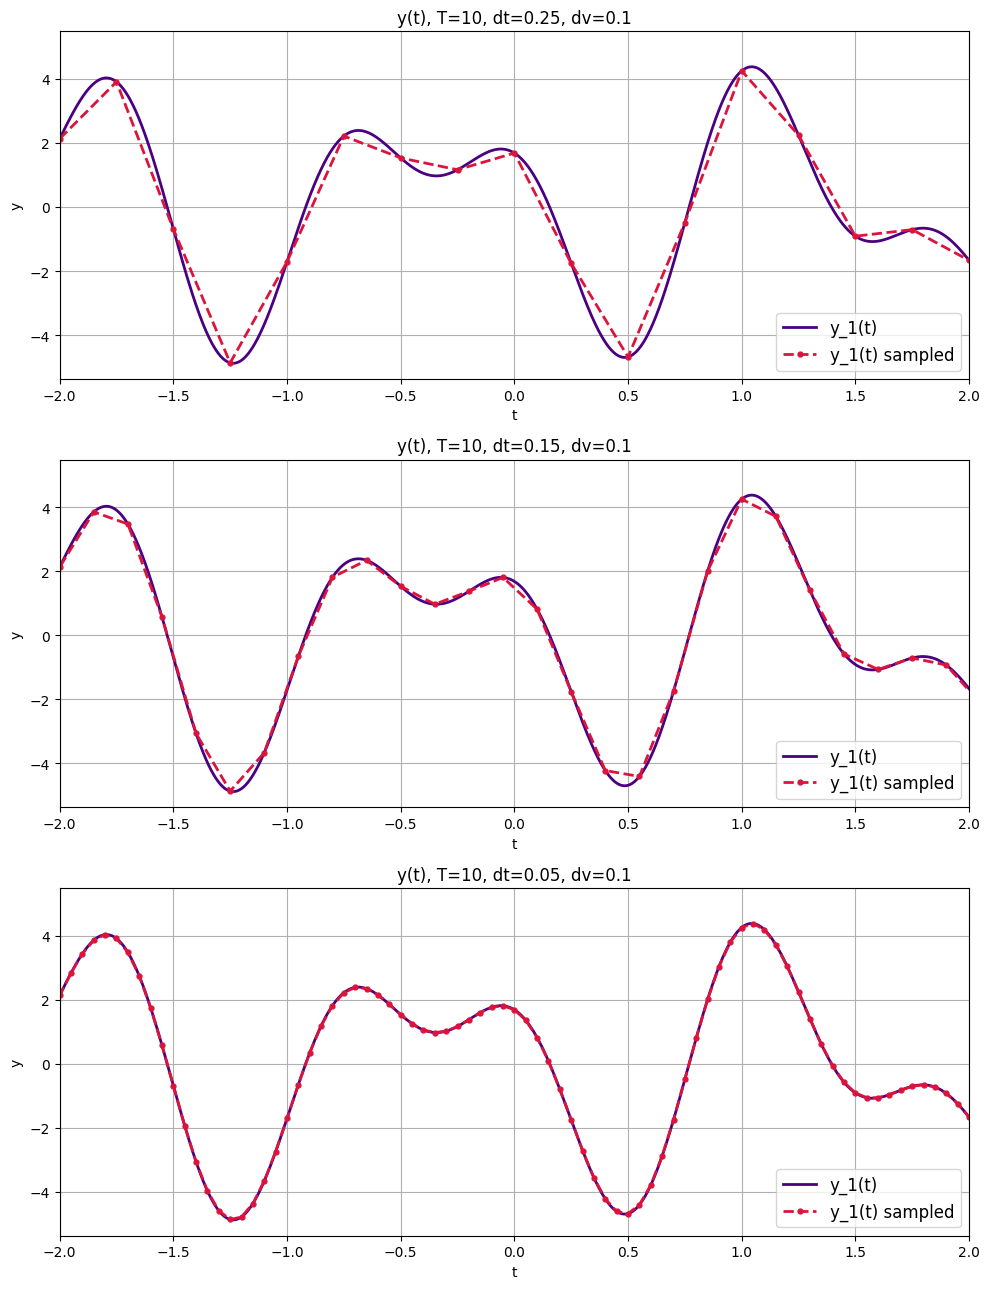

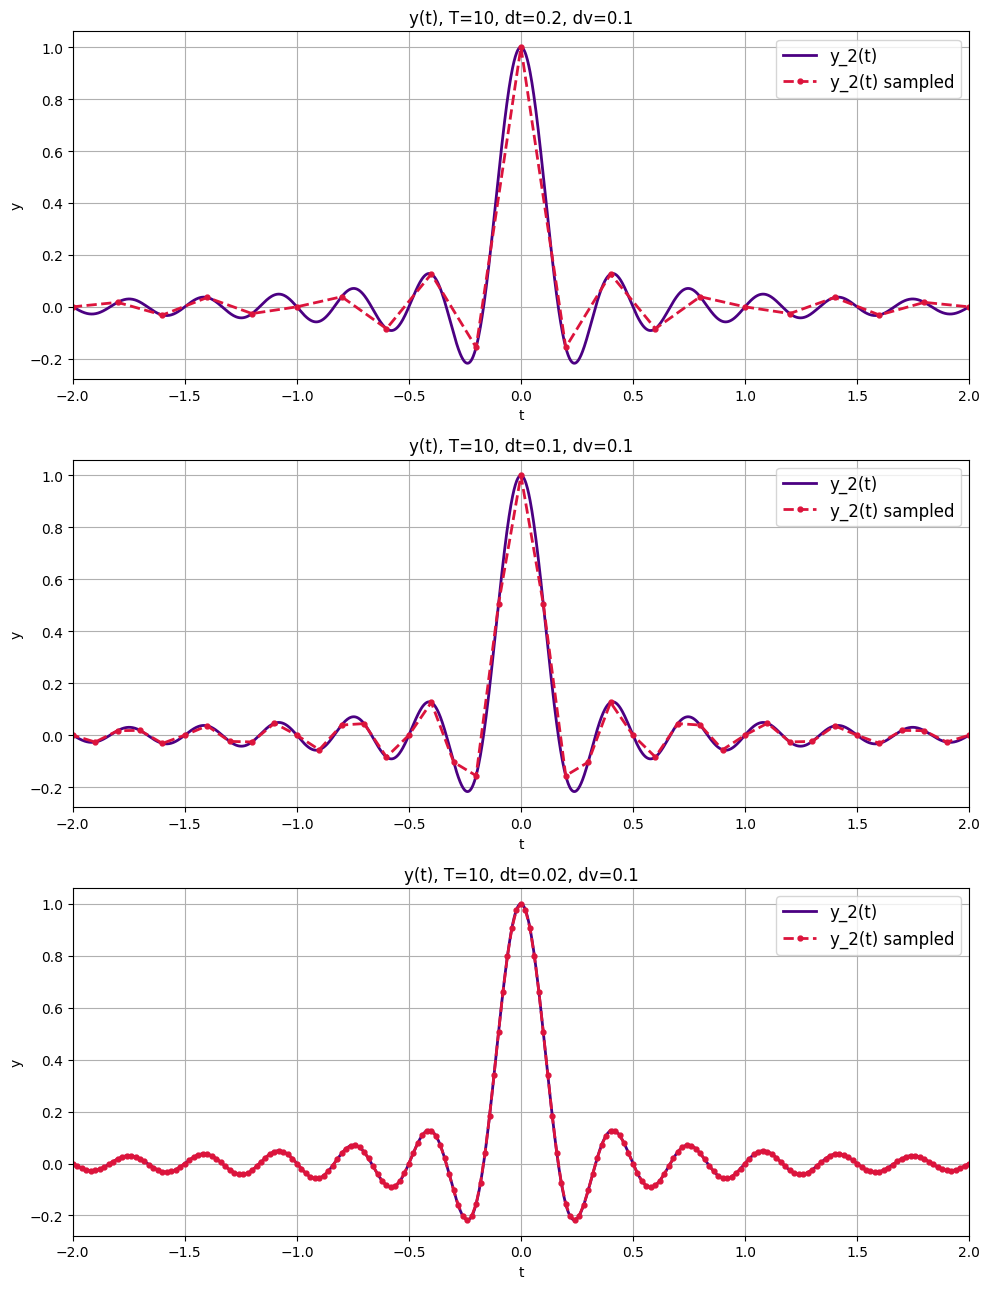

In [17]:
dt_list = [0.25, 0.15, 0.05]

chart = Chart(3, 1, 10, 13)

T = 10
for dt in dt_list:
    x_sampled = np.arange(-T/2, T/2, dt)
    y1_disc = y1(x_sampled)
    plt_g = Plot_Group(f"y(t), T={T}, dt={round(dt, 3)}, dv={round(1/T, 3)}", "t", "y", xlim=(-2, 2), legend=True, legend_fontsize="large")
    plt_g.add_plot(Plot(x, y1_cont, "y_1(t)", color="indigo", linewidth=2))
    plt_g.add_plot(Plot(x_sampled, y1_disc, "y_1(t) sampled", color="crimson",
                        linewidth=2, linestyle="--", marker=".", markersize=7))
    chart.add_plot_group(plt_g)
    del plt_g

    
chart.save_chart(plt_folder, "y1_comparison", dpi=200)
del chart

dt_list = [0.2, 0.1, 0.02]

chart = Chart(3, 1, 10, 13)
for dt in dt_list:
    x_sampled = np.arange(-T/2, T/2, dt)
    y2_disc = y2(x_sampled)
    plt_g = Plot_Group(f"y(t), T={T}, dt={round(dt, 3)}, dv={round(1/T, 3)}", "t", "y", xlim=(-2, 2), legend=True, legend_fontsize="large")
    plt_g.add_plot(Plot(x, y2_cont, "y_2(t)", color="indigo", linewidth=2))
    plt_g.add_plot(Plot(x_sampled, y2_disc, "y_2(t) sampled", color="crimson",
                        linewidth=2, linestyle="--", marker=".", markersize=7))
    chart.add_plot_group(plt_g)
    del plt_g

    
chart.save_chart(plt_folder, "y2_comparison", dpi=200)
del chart

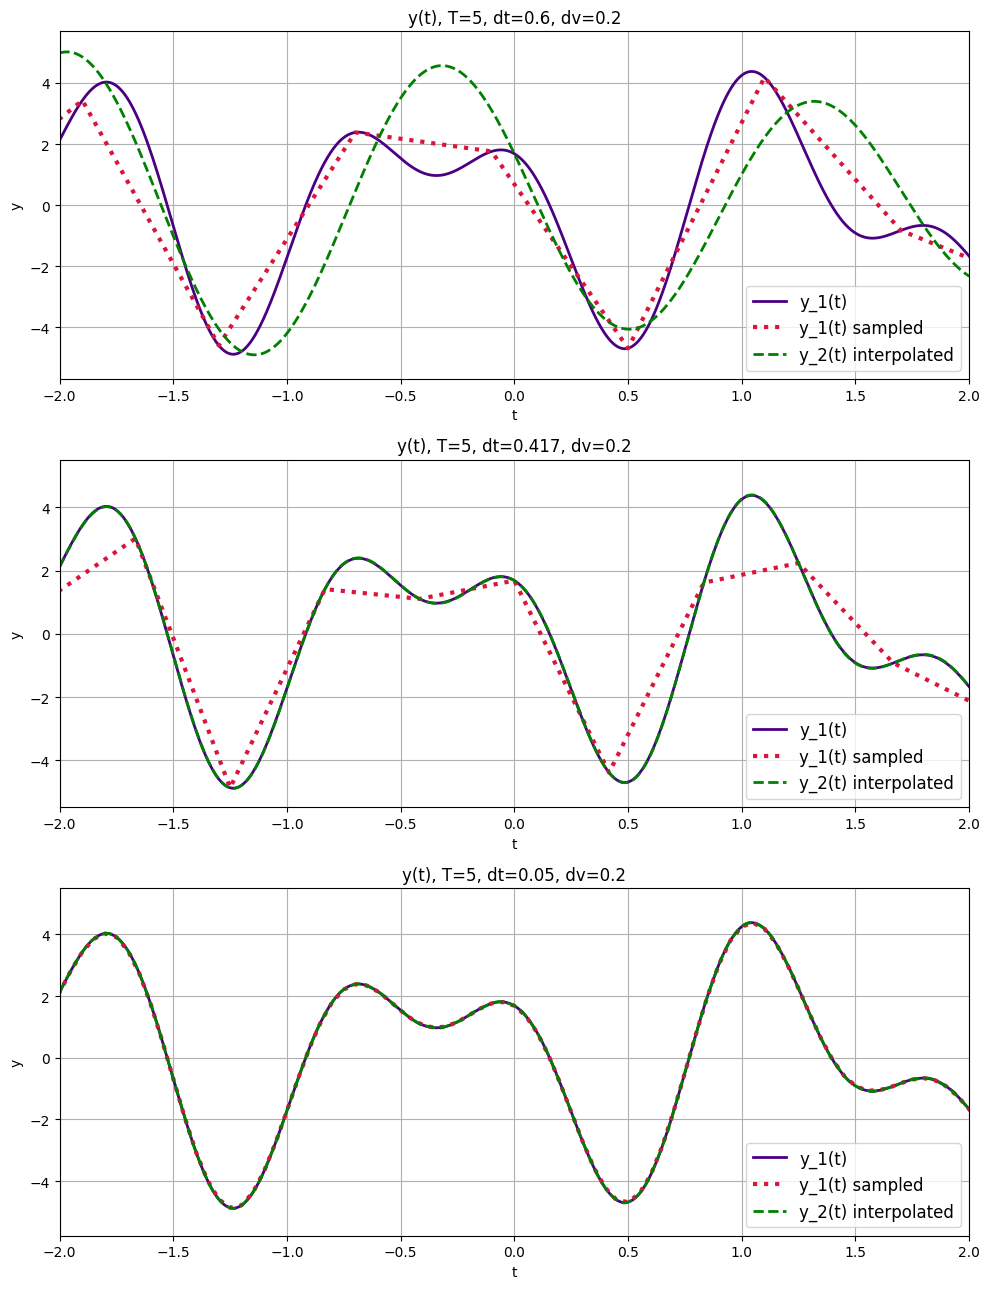

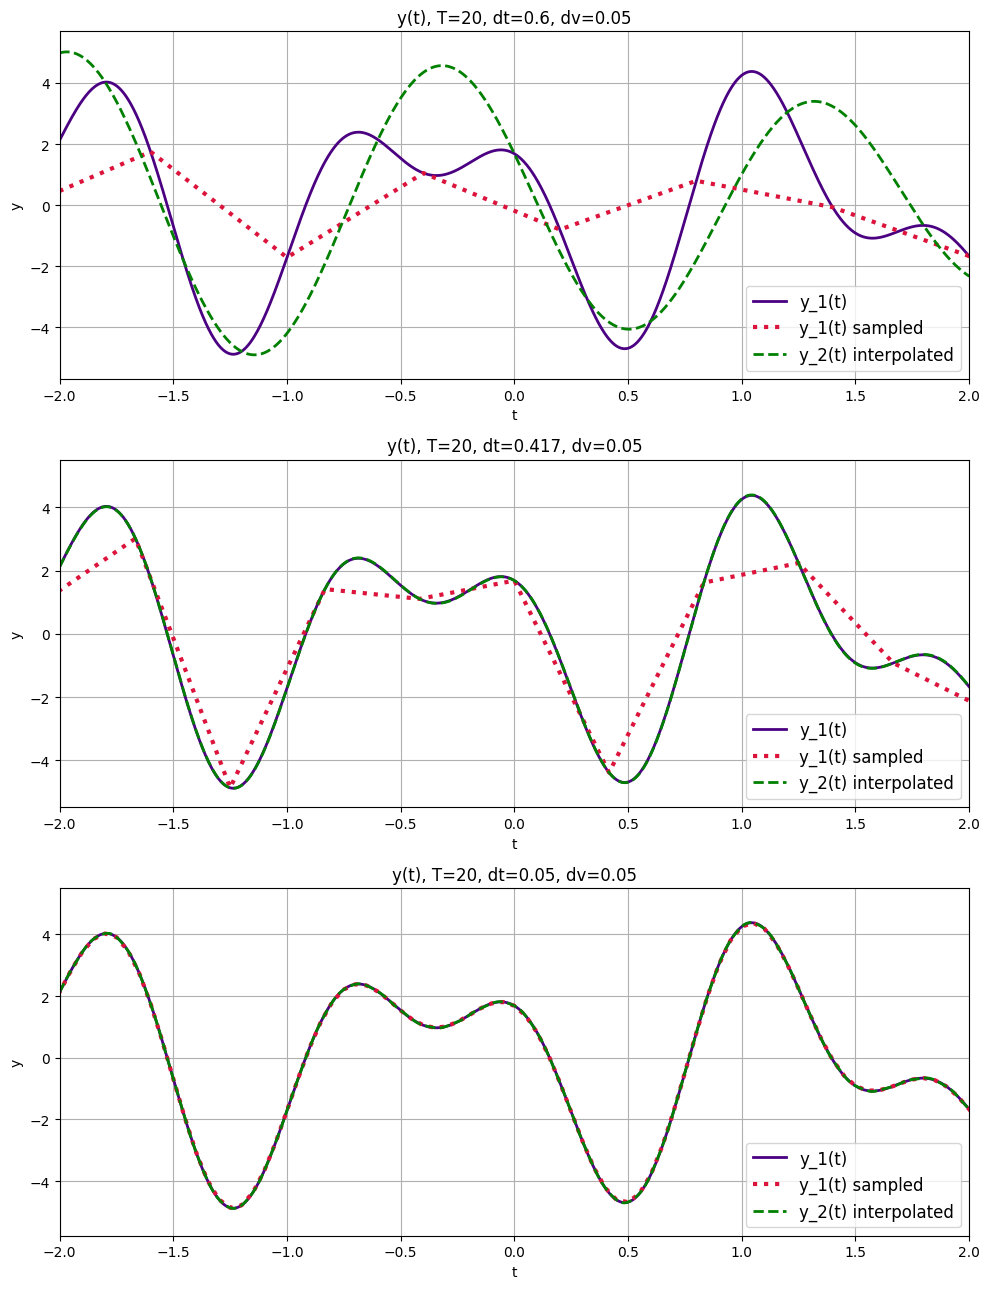

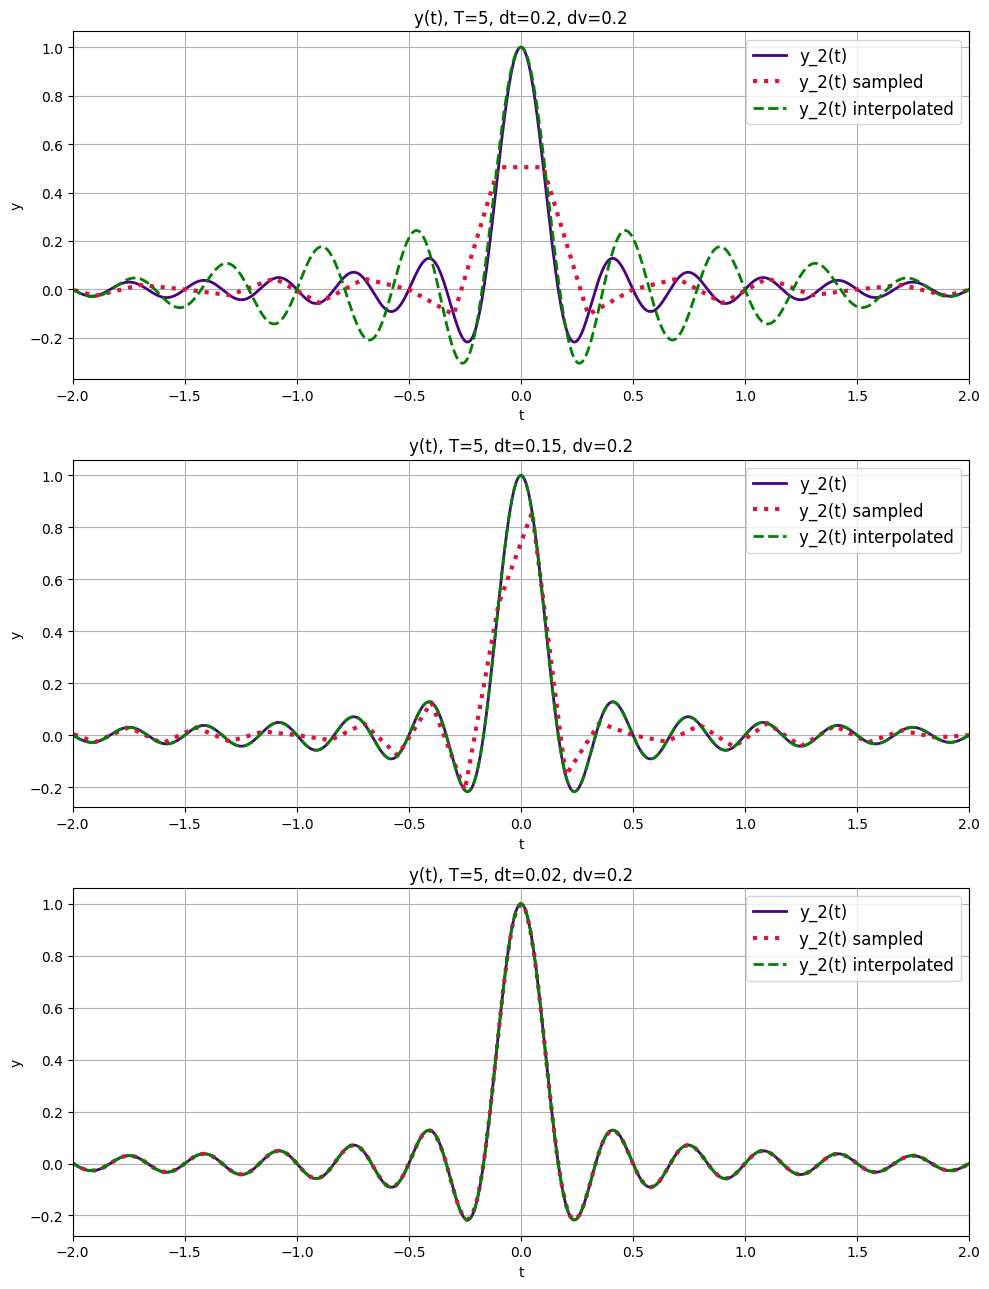

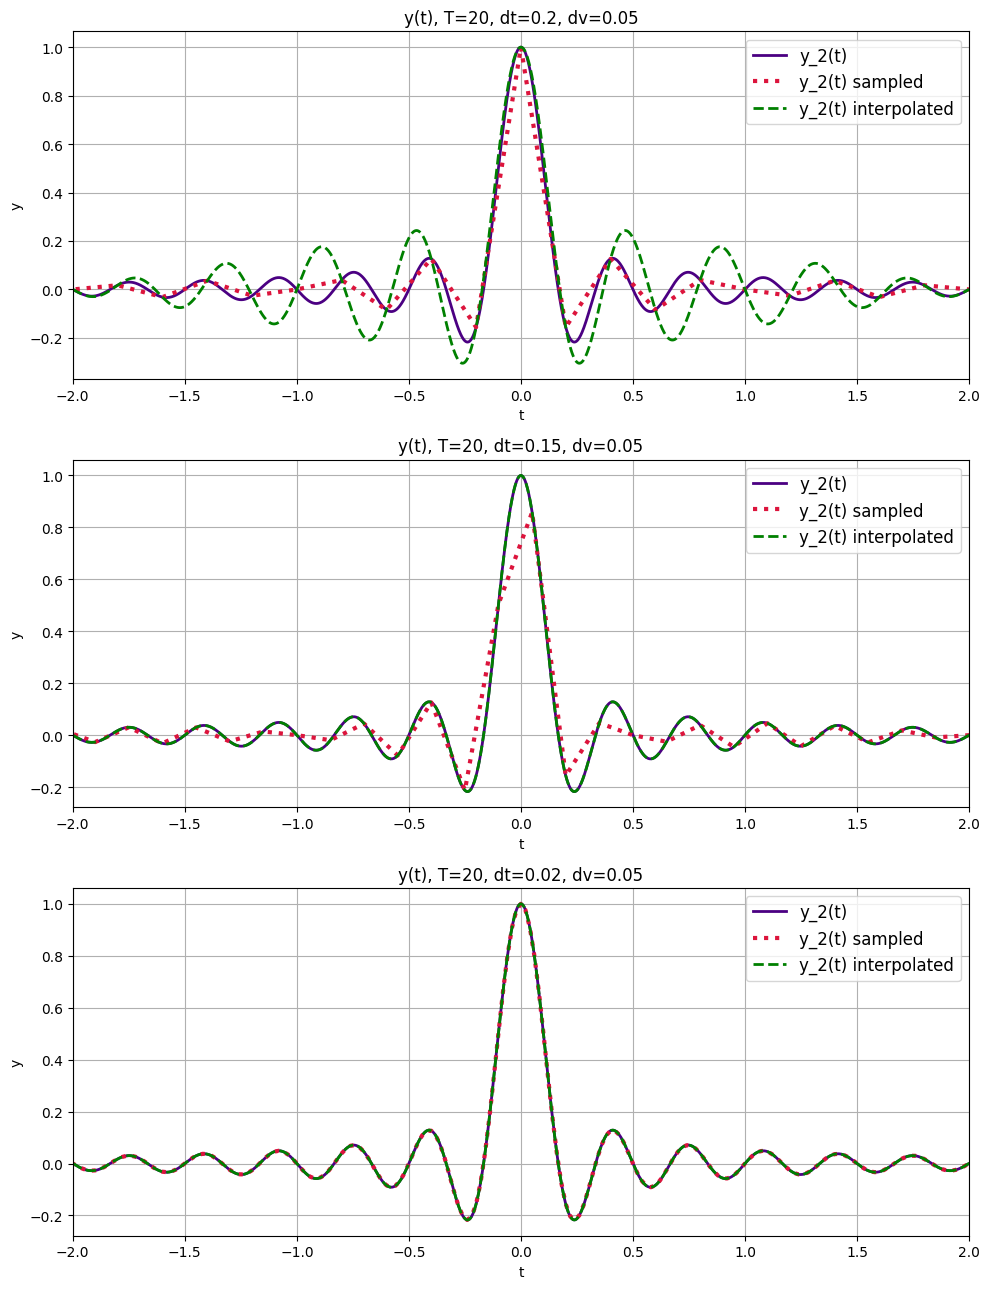

In [18]:
def interpolate(func, dt, t):
    f_interpolated = np.zeros(len(t))
    for n in range(-100, 101):
        tn = n * dt
        f_interpolated += func([tn]) * np.sin(np.pi / dt * (t - tn)) / (np.pi / dt * (t - tn))
    return f_interpolated

B1 =  1.2
B2 = 3
T_list = [5, 20]

dt_list = [0.6, 1 / 2 / B1, 0.05]
y1_cont = y1(x)
y2_cont = y2(x)

for T in T_list:
    chart = Chart(3, 1, 10, 13)
    for dt in dt_list:
        x_sampled = np.arange(-T/2, T/2, dt)
        y1_disc = y1(x_sampled)
        y1_interp = interpolate(y1, dt, x)
        plt_g = Plot_Group(f"y(t), T={T}, dt={round(dt, 3)}, dv={round(1/T, 3)}", "t", "y", xlim=(-2, 2), legend=True, legend_fontsize="large")
        plt_g.add_plot(Plot(x, y1_cont, "y_1(t)", color="indigo", linewidth=2))
        plt_g.add_plot(Plot(x_sampled, y1_disc, "y_1(t) sampled", color="crimson",
                            linewidth=3, linestyle=":"))
        plt_g.add_plot(Plot(x, y1_interp, "y_2(t) interpolated", color="green",
                            linewidth=2, linestyle="--"))
        chart.add_plot_group(plt_g)
        del plt_g
    
    chart.save_chart(plt_folder, f"y1_interp_{T}", dpi=200)
    del chart

dt_list = [0.2, 0.15, 0.02]
for T in T_list:
    chart = Chart(3, 1, 10, 13)
    for dt in dt_list:
        x_sampled = np.arange(-T/2, T/2, dt)
        y2_disc = y2(x_sampled)
        y2_interp = interpolate(y2, dt, x)
        plt_g = Plot_Group(f"y(t), T={T}, dt={round(dt, 3)}, dv={round(1/T, 3)}", "t", "y", xlim=(-2, 2), legend=True, legend_fontsize="large")
        plt_g.add_plot(Plot(x, y2_cont, "y_2(t)", color="indigo", linewidth=2))
        plt_g.add_plot(Plot(x_sampled, y2_disc, "y_2(t) sampled", color="crimson",
                            linewidth=3, linestyle=":"))
        plt_g.add_plot(Plot(x, y2_interp, "y_2(t) interpolated", color="green",
                            linewidth=2, linestyle="--"))
        chart.add_plot_group(plt_g)
        del plt_g
        
    chart.save_chart(plt_folder, f"y2_interp_{T}", dpi=200)
    del chart

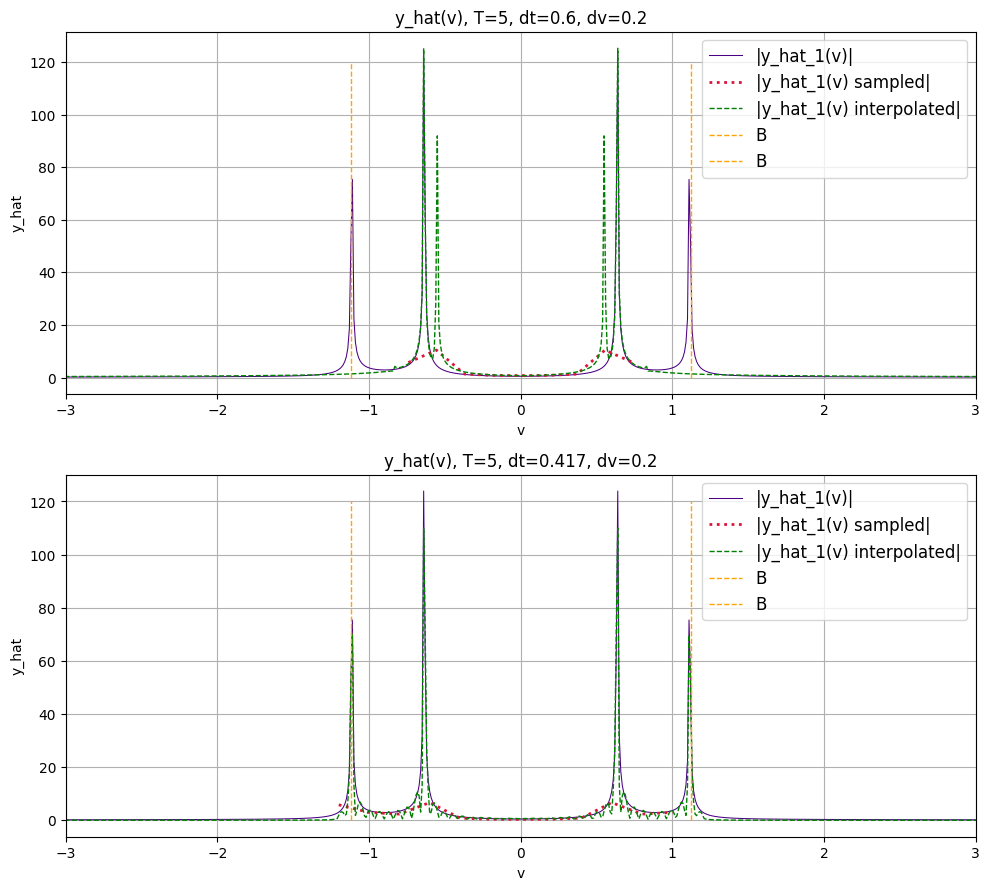

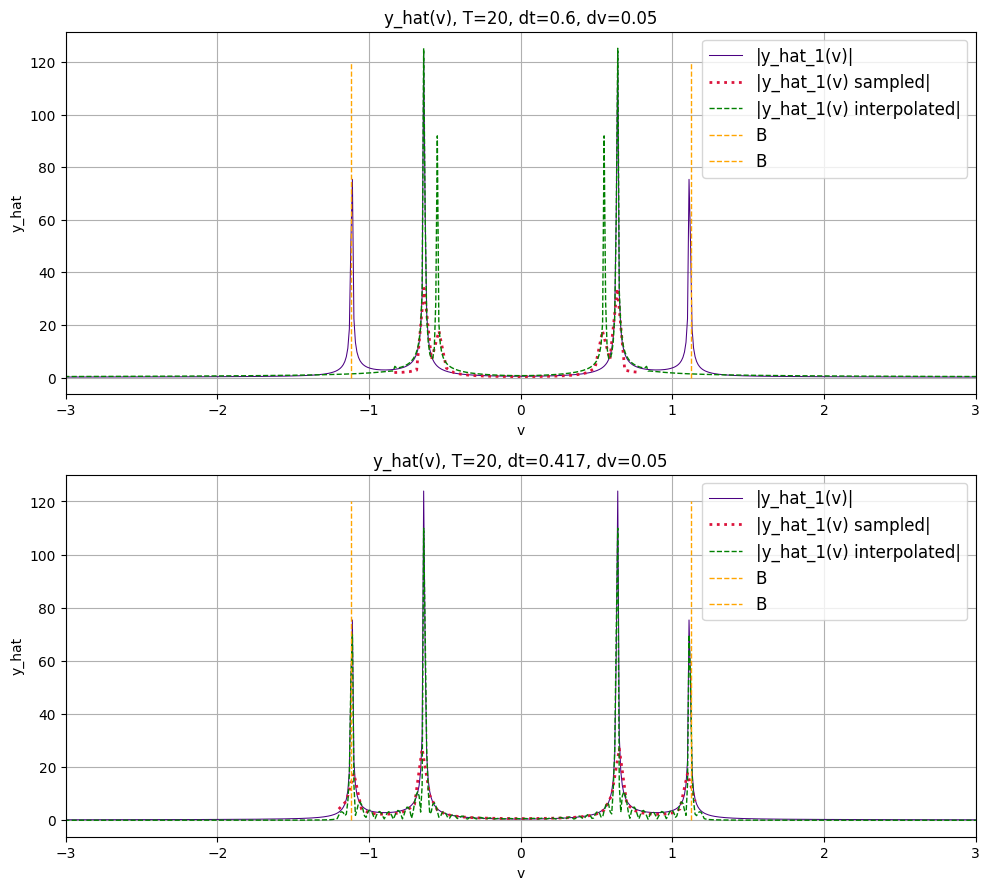

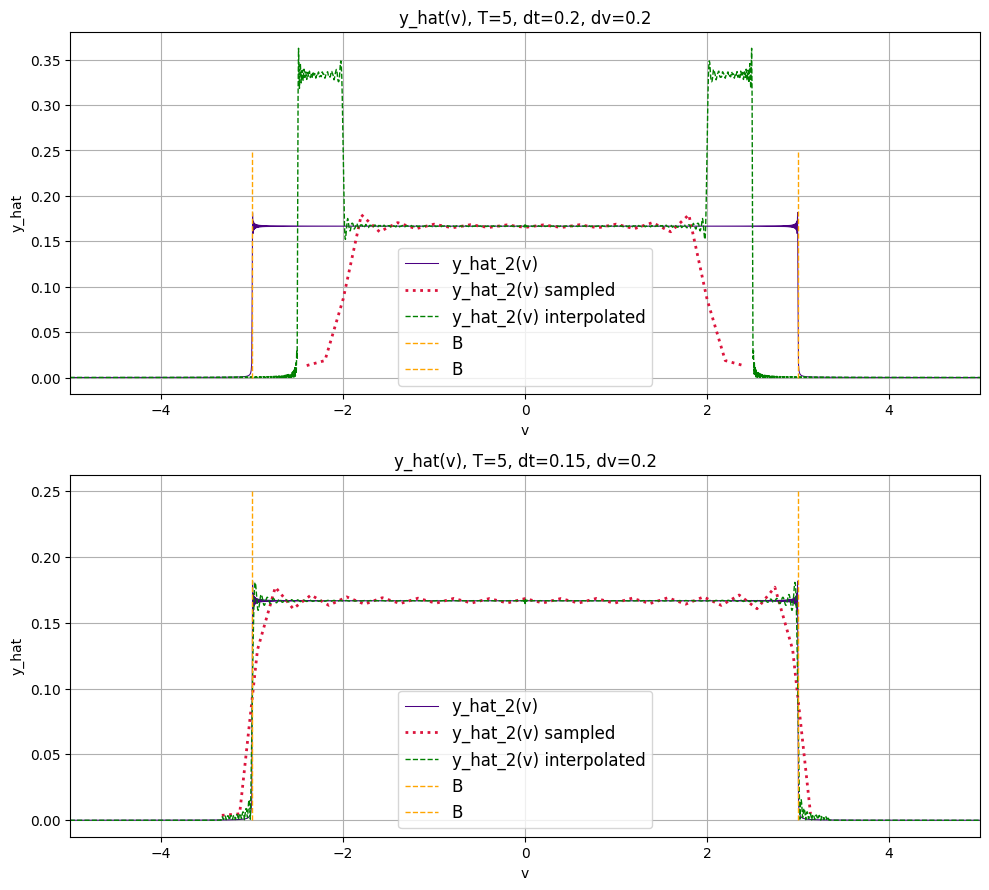

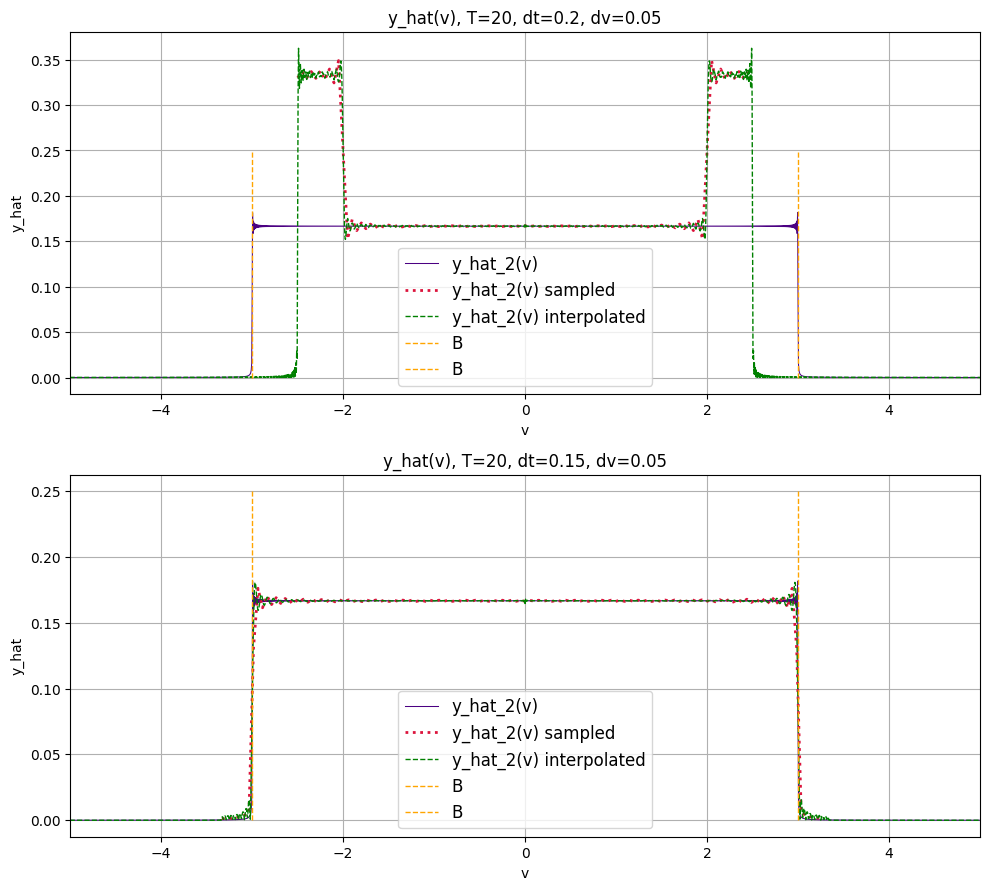

In [21]:
dt_list = [0.6, 1 / 2 / B1]
T_list = [5, 20]
x = np.arange(-50.0, 50.0, 0.001)
for T in T_list:
    chart = Chart(3, 1, 10, 13)
    for dt in dt_list:
        x_sampled = np.arange(-T/2, T/2 + dt, dt)
        y1_interp = interpolate(y1, dt, x)
        
        @list_func
        def y1i(t):
            idx = np.abs(x - t).argmin()
            return y1_interp[idx]
        
        y_hat_1_cont, v_space_cont = smart_fft(y1, 100, 0.001)
        y_hat_1_interp, v_space_interp = smart_fft(y1i, 100, 0.001)
        y_hat_1_disc, v_space_ds = smart_fft(y1, T, dt)

        plt_g = Plot_Group(f"y_hat(v), T={T}, dt={round(dt, 3)}, dv={round(1/T, 3)}", "v", "y_hat", xlim=(-3, 3), legend=True, legend_fontsize="large")
        plt_g.add_plot(Plot(v_space_cont, np.abs(y_hat_1_cont), "|y_hat_1(v)|", color="indigo", linewidth=0.75))
        plt_g.add_plot(Plot(v_space_ds, np.abs(y_hat_1_disc), "|y_hat_1(v) sampled|", color="crimson",
                            linewidth=2, linestyle=":"))
        plt_g.add_plot(Plot(v_space_interp, np.abs(y_hat_1_interp), "|y_hat_1(v) interpolated|", color="green",
                            linewidth=1, linestyle="--"))
        xB = [1.12] *2
        yB = [0, 120]
        plt_g.add_plot(Plot(xB, yB, "B", "orange", linestyle="--"))
        xBm = [-1.12] *2
        yBm = [0, 120]
        plt_g.add_plot(Plot(xBm, yBm, "B", "orange", linestyle="--"))
        chart.add_plot_group(plt_g)
        del plt_g
    
    chart.save_chart(plt_folder, f"y_hat_1_interp_{T}", dpi=200)
    del chart

dt_list = [0.2, 0.15]
for T in T_list:
    chart = Chart(3, 1, 10, 13)
    for dt in dt_list:
        x_sampled = np.arange(-T/2, T/2, dt)
        y2_interp = interpolate(y2, dt, x)

        @list_func
        def y2i(t):
            idx = np.abs(x - t).argmin()
            return y2_interp[idx]
        
        y_hat_2_cont, v_space_cont = smart_fft(y2, 200, 0.001)
        y_hat_2_interp, v_space_interp = smart_fft(y2i, 200, 0.001)
        y_hat_2_disc, v_space_ds = smart_fft(y2, T, dt)

        plt_g = Plot_Group(f"y_hat(v), T={T}, dt={round(dt, 3)}, dv={round(1/T, 3)}", "v", "y_hat", xlim=(-5, 5), legend=True, legend_fontsize="large")
        plt_g.add_plot(Plot(v_space_cont, np.abs(y_hat_2_cont), "y_hat_2(v)", color="indigo", linewidth=0.75))
        plt_g.add_plot(Plot(v_space_ds, np.abs(y_hat_2_disc), "y_hat_2(v) sampled", color="crimson",
                            linewidth=2, linestyle=":"))
        plt_g.add_plot(Plot(v_space_interp, np.abs(y_hat_2_interp), "y_hat_2(v) interpolated", color="green",
                            linewidth=1, linestyle="--"))
        xB = [3] *2
        yB = [0, 0.25]
        plt_g.add_plot(Plot(xB, yB, "B", "orange", linestyle="--"))
        xBm = [-3] *2
        yBm = [0, 0.25]
        plt_g.add_plot(Plot(xBm, yBm, "B", "orange", linestyle="--"))
        chart.add_plot_group(plt_g)
        del plt_g
        
    chart.save_chart(plt_folder, f"y_hat_2_interp_{T}", dpi=200)
    del chart